<h1 align="center">ASSIGNMENT 2</h1>
<h2 align="center">Intelligent Data Analysis</h2>
<h2 align="center">DV1597</h2>
<h3 align="center">Group 9</h3>
<h3 align="center">Grace Dona Harlita Tarihoran (grta26@student.bth.se)</h3>

# Introduction
The assignment aims to perform explanatory data analysis on the provided datasets. This assignment involves importing a few datasets from an external file to a suitable Python data structure. It may include handling various data cleaning tasks and transformations, as well as aggregating the data in different ways. Finally, you are expected to perform data-driven analyses to answer the questions.

## Data Understanding
The three datasets used for this assignment are from the European Centre for Disease Prevention and Control (ECDC) from 2020 to 2022. The data is publicly available and contains information about the coronavirus pandemic, such as:
1. The number of COVID-19 cases and deaths
2. Current occupancy and vaccination across the EU/EEA
3. Hospitalization and Intensive Care Unit (ICU) admission rates

## Data Loading & Initial Inspection
In this section, we load the three ECDC datasets into Pandas DataFrames and inspect their shapes, column data types, and initial rows to understand the data structure.

### Import libraries

In [63]:
# Import the main libraries needed for data analysis
import pandas as pd
import numpy as np

# Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import statistical tests for correlation analysis
from scipy.stats import pearsonr, spearmanr

### Loading datasets

In [64]:
# Load the COVID-19 daily cases and deaths dataset
cases_df = pd.read_csv("1.COVID-19_daily_number_of_new_cases_and_deaths.csv")

# Load the COVID-19 vaccination dataset
vacc_df = pd.read_csv("2.COVID-19_vaccination.csv")

# Load the hospital and ICU admission dataset
hospital_df = pd.read_csv("3.COVID-19_hospital_and_ICU_admission_rates.csv")

### Initial data overview

In [65]:
# Cases and deaths dataset overview
print("-- Cases and deaths dataset overview --")
print("Cases and deaths dataset:", cases_df.shape) # Display the shape of dataset to see the number of rows and columns
display(cases_df.head()) # Inspect the first five rows of the cases and deaths dataset
display(cases_df.info()) # Check column names, data types, and non-null values
print("Missing values:")
display(cases_df.isnull().sum()) # Check missing values in each column
print("Duplicate rows:", cases_df.duplicated().sum()) # Check duplicate rows
display(cases_df.describe()) # Show basic descriptive statistics

# Vaccination dataset overview
print("\n-- Vaccination dataset overview --")
print("Vaccination dataset:", vacc_df.shape) # Display the shape of dataset to see the number of rows and columns
display(vacc_df.head()) # Inspect the first five rows of the vaccination dataset
display(vacc_df.info()) # Check column names, data types, and non-null values
print("Missing values:")
display(vacc_df.isnull().sum()) # Check missing values in each column
print("Duplicate rows:", vacc_df.duplicated().sum()) # Check duplicate rows
display(vacc_df.describe()) # Show basic descriptive statistics

# Hospital dataset overview
print("\n-- Hospital dataset overview--")
print("Hospital dataset:", hospital_df.shape) # Display the shape of dataset to see the number of rows and columns
display(hospital_df.head()) # Inspect the first five rows of the hospital dataset
display(hospital_df.info()) # Check column names, data types, and non-null values
print("Missing values:")
display(hospital_df.isnull().sum()) # Check missing values in each column
print("Duplicate rows:", hospital_df.duplicated().sum()) # Check duplicate rows
display(hospital_df.describe()) # Show basic descriptive statistics

-- Cases and deaths dataset overview --
Cases and deaths dataset: (28729, 11)


,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2020,continentExp
0,23/10/2022,23,10,2022,3557.0,0.0,Austria,AT,AUT,8901064,Europe
1,22/10/2022,22,10,2022,5494.0,4.0,Austria,AT,AUT,8901064,Europe
2,21/10/2022,21,10,2022,7776.0,4.0,Austria,AT,AUT,8901064,Europe
3,20/10/2022,20,10,2022,8221.0,6.0,Austria,AT,AUT,8901064,Europe
4,19/10/2022,19,10,2022,10007.0,8.0,Austria,AT,AUT,8901064,Europe


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28729 entries, 0 to 28728
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   dateRep                  28729 non-null  object 
 1   day                      28729 non-null  int64  
 2   month                    28729 non-null  int64  
 3   year                     28729 non-null  int64  
 4   cases                    28636 non-null  float64
 5   deaths                   28437 non-null  float64
 6   countriesAndTerritories  28729 non-null  object 
 7   geoId                    28729 non-null  object 
 8   countryterritoryCode     28729 non-null  object 
 9   popData2020              28729 non-null  int64  
 10  continentExp             28729 non-null  object 
dtypes: float64(2), int64(4), object(5)
memory usage: 2.4+ MB


None

Missing values:


...

None

Missing values:


country          0
indicator        0
date             0
year_week        0
value            0
source           0
url          25100
dtype: int64

Duplicate rows: 0


,value,url
count,25100.000000,0.0
mean,818.736440,NaN
std,2540.068028,NaN
min,0.000000,NaN
25%,8.000000,NaN
50%,70.000000,NaN
75%,514.000000,NaN
max,36403.000000,NaN


**Datasets observation**

**A. Cases and Deaths Data**
1. Shape: the dataset contains 28,729 rows and 11 columns.
2. Missing values in 2 columns:
    - `cases` contains 93 (0.3%) missing values
    - `deaths` contains 292 (1%) missing values
3. Duplicate rows: no duplicate values.
4. Negative values in 2 columns:
    - `cases` contains 14 negative values
    - `deaths` contains 17 negative values

**B. Vaccination Data**
1. Shape: the dataset contains 681,330 rows and 18 columns.
2. Missing values in 4 columns:
    - `Denominator` contains 319,779 (46.9%) missing values
    - `NumberDosesReceived` contains 595,499 (87.4%) missing values
    - `NumberDosesExported` contains 590,036 (86.8%) missing values
    - `FirstDoseRefused` contains 679,883 (99,78%) missing values
3. Duplicate rows: no duplicate values.

**C. Hospital Data**
1. Shape: the dataset contains 25,100 rows and 7 columns.
2. Missing values in column `url` contain 25,100 (100%) missing values
3. Duplicate rows: no duplicate values.

# Data Cleaning
## Handling Negative and Missing Values
After analyzing the presence of missing (null) values across the datasets, we will handle them using any of the following methods: imputation, removal, or retention, depending on the context of the questions.

**A. Cases and Deaths Data**
The dataset contains both missing and negative values. We can't just remove the values because it is a time series dataset. Since a country cannot have a negative number of people getting sick or dying on a given day, these negative numbers represent data corrections. The best ways to handle both negative and missing values are:

**1. Convert negative values to NaN**: Because negative values represent retroactive historical corrections (adjusting for previous overcounting), leaving them as large negative numbers creates unnatural downward drops on charts. Converting them to NaN allows you to treat them exactly like missing records.

**2. Convert dates and sort chronologically: The dataset is currently organized in reverse-chronological order (newest dates first). Time-series interpolation only works correctly if the data flows forward from oldest to newest.

**3. Imppute with 0**: imputing with zero values indicates that there were no reported cases that day, which is normal.

**4. Handle Edge Cases with Zero-Filling**: If a missing or negative value occurs on the very first recorded day for a country, linear interpolation cannot look backward to find a starting point. Adding a final .fillna(0) catches these rare edge cases.

We prioritized preserving the epidemiological timeline and daily transmission trends over the administrative reporting corrections. While replacing negative values with interpolated data slightly increases the absolute cumulative totals by bypassing retroactive deductions, it prevents artificial, non-physical spikes from distorting our quarterly time-series analysis and graphical visualizations.

**Motivation for Preprocessing Methodology**:
- Retention over Removal: Deleting rows containing missing or negative data would rupture the continuous chronological sequence required for tracking an epidemic over time.
- Treatment of Negative Values: Negative counts represent retroactive public health accounting corrections rather than physical realities. Converting them to NaN allows us to handle them systematically alongside standard missing fields without introducing unnatural drops in daily trend lines.
- Linear Interpolation: Since pandemic data moves in waves and sequential trends, linear interpolation provides an empirically grounded estimate of missing daily counts based on surrounding reporting days, ensuring smooth curves for analytical tracking.
- Country-Level Grouping: Interpolation must be localized within each country entity via a groupby operation to prevent regional epidemiological data from bleeding across unrelated nations.</br>

In [66]:
print("=== CASES DATA: BEFORE CLEANING ===")
print(cases_df[['cases', 'deaths']].isnull().sum())
print("Negative cases:", (cases_df['cases'] < 0).sum())
print("Negative deaths:", (cases_df['deaths'] < 0).sum())

# Convert date
cases_df['dateRep'] = pd.to_datetime(cases_df['dateRep'], format='%d/%m/%Y')

# Replace impossible negative values with NaN
cases_df.loc[cases_df['cases'] < 0, 'cases'] = np.nan
cases_df.loc[cases_df['deaths'] < 0, 'deaths'] = np.nan

# Sort before interpolation
cases_df = cases_df.sort_values(
    by=['countriesAndTerritories', 'dateRep']
).reset_index(drop=True)

# Fill missing cases/ deaths column within each country with 0
cases_df[['cases', 'deaths']] = cases_df[['cases', 'deaths']].fillna(0)

# Create useful time variables
cases_df['year'] = cases_df['dateRep'].dt.year
cases_df['quarter'] = cases_df['dateRep'].dt.quarter
cases_df['month'] = cases_df['dateRep'].dt.month

print("\n=== CASES DATA: AFTER CLEANING ===")
print(cases_df[['cases', 'deaths']].isnull().sum())
print("Negative cases:", (cases_df['cases'] < 0).sum())
print("Negative deaths:", (cases_df['deaths'] < 0).sum())

=== CASES DATA: BEFORE CLEANING ===
cases      93
deaths    292
dtype: int64
Negative cases: 14
Negative deaths: 17

=== CASES DATA: AFTER CLEANING ===
cases     0
deaths    0
dtype: int64
Negative cases: 0
Negative deaths: 0


**B. Vaccination Data**

This dataset is an aggregated weekly categorical dataset sliced by country, target group, and vaccine brand. Applying a time-series linear interpolation here would skew the data. Instead, our contextual approach tells us exactly what these blanks mean:
1. `NumberDosesReceived`, `NumberDosesExported`, and `FirstDoseRefused` $\rightarrow$ Fill with 0
   - Action: Impute these missing values with 0. This is mathematically safe and allows you to perform clean summations.
   - Why: In public vaccine logistics reporting, if a row tracking a specific vaccine brand (e.g., Novavax) for a specific age group during a specific week is blank under doses received or exported, it is because no doses were received, exported, or refused for that combination.

3. `Denominator` $\rightarrow$ Retention (Keep as NaN or handle per query)
   - What it is: The Denominator represents the size of the specific target group within that country (e.g., the number of healthcare workers or the population of the Age70_79 bracket).
    - Action: Leave these as NaN during data ingestion. When we use it later to approach questions like Question 6 (ranking under-18 vaccination rates), we can dynamically drop rows where the target group denominator is missing, or divide the doses by the country's total Population column instead, depending on what the question specifies.
   - Why: Countries often lacked accurate, dynamic data for specific occupational subgroups (like healthcare workers, HCW, or long-term care facility residents, LTCF), or general unclassified categories (AgeUNK). Filling this column with a static value (like `0`) would result in critical "Division by Zero" (`inf`) errors when computing vaccine uptake rates ($\frac{\text{FirstDose}}{\text{Denominator}}$) later in Section 3. Imputing with a mean or median would create false population statistics across unrelated countries. Leaving these entries as `NaN` preserves data authenticity, allowing us to drop or circumvent them dynamically and safely on a per-question basis.
   

In [67]:
print("=== VACCINATION DATA: BEFORE CLEANING ===")
print(vacc_df.isnull().sum())

# Fill logistical/count-related columns with 0
logistical_cols = [
    'NumberDosesReceived',
    'NumberDosesExported',
    'FirstDoseRefused'
]

vacc_df[logistical_cols] = vacc_df[logistical_cols].fillna(0)

# Replace impossible negative numeric values with NaN
vacc_numeric_cols = vacc_df.select_dtypes(include='number').columns

for col in vacc_numeric_cols:
    vacc_df.loc[vacc_df[col] < 0, col] = np.nan

# Extract year and week
vacc_df['year'] = vacc_df['YearWeekISO'].str[:4].astype(int)
vacc_df['week'] = vacc_df['YearWeekISO'].str[-2:].astype(int)

print("\n=== VACCINATION DATA: AFTER CLEANING ===")
print(vacc_df.isnull().sum())

=== VACCINATION DATA: BEFORE CLEANING ===
YearWeekISO                 0
ReportingCountry            0
Denominator            319779
NumberDosesReceived    595499
NumberDosesExported    590036
FirstDose                   0
FirstDoseRefused       679883
SecondDose                  0
DoseAdditional1             0
DoseAdditional2             0
DoseAdditional3             0
DoseAdditional4             0
DoseAdditional5             0
UnknownDose                 0
Region                      0
TargetGroup                 0
Vaccine                     0
Population                  0
dtype: int64

=== VACCINATION DATA: AFTER CLEANING ===
YearWeekISO                 0
ReportingCountry            0
Denominator            319779
NumberDosesReceived         0
NumberDosesExported         0
FirstDose                   0
FirstDoseRefused            0
SecondDose                  0
DoseAdditional1             0
DoseAdditional2             0
DoseAdditional3             0
DoseAdditional4             0
Dos

**C. Hospital Data**
An evaluation of the hospital and ICU rates dataset revealed a highly localized and non-critical pattern of missing values:
1. **Remove column `url`:** 
    - Why: The `url` attribute is entirely unpopulated (containing 100% missing values across all 25,100 records). Because an entirely blank column provides no statistical variance or administrative value, and since external data reference links are completely irrelevant to resolving the core assignment questions (such as analyzing healthcare system load in Questions 5 and 8),
    - Action: The entire column was systematically dropped via `df.drop(columns=['url'])`. Removing it optimizes memory performance and declutters our working data structures without altering any epidemiological data.
2. **Add new columns: `Year`, `Month`, `Quarter`**:  Additional temporal variables such as year, month, and quarter were extracted from the date column to support time-based analysis and visualization.

In [68]:
print("\n=== HOSPITAL DATA: BEFORE CLEANING ===")
print(hospital_df.isnull().sum())

# Drop url column because it is empty and not useful
hospital_df = hospital_df.drop(columns=['url'], errors='ignore')

# Convert date
hospital_df['date'] = pd.to_datetime(hospital_df['date'], format='%Y-%m-%d')

# Replace impossible negative values with NaN
hospital_df.loc[hospital_df['value'] < 0, 'value'] = np.nan

# Sort before interpolation
hospital_df = hospital_df.sort_values(
    by=['country', 'indicator', 'date']
).reset_index(drop=True)

# Interpolate missing values within each country and indicator
hospital_df['value'] = (
    hospital_df.groupby(['country', 'indicator'])['value']
    .transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
)

# Fill remaining missing values with 0 if interpolation cannot solve them
hospital_df['value'] = hospital_df['value'].fillna(0)

print("\n=== HOSPITAL DATA: AFTER CLEANING ===")
print(hospital_df.isnull().sum())
print("Negative values:", (hospital_df['value'] < 0).sum())
print("Cleaned hospital dataset shape:", hospital_df.shape)


=== HOSPITAL DATA: BEFORE CLEANING ===
country          0
indicator        0
date             0
year_week        0
value            0
source           0
url          25100
dtype: int64

=== HOSPITAL DATA: AFTER CLEANING ===
country      0
indicator    0
date         0
year_week    0
value        0
source       0
dtype: int64
Negative values: 0
Cleaned hospital dataset shape: (25100, 6)


# Outlier Detection and Analysis

We will investigate whether the outliers exist using plots. Because COVID-19 data naturally contains extreme values due to:
- pandemic waves
- vaccination campaigns
- ICU surges
- delayed reporting

So outliers in these datasets are meaningful information, not mistakes, so we then keep them unless they are clearly errors later.

**A. Cases and Deaths Data**

This dataset contains continuous, daily sequential data. Pandemic data naturally grows exponentially during a wave. To show the outliers, I chose a line plot.

**Why the Line Plot is better**: A time-series line plot preserves the chronological order. This allows our eyes to see the smooth, natural rise and fall of an epidemic wave, making administrative outliers stick out instantly, so it is good to:
- identifying spikes
- understanding waves
- distinguishing real events vs anomalies

The Problem with a Boxplot here: If you look at a country's entire timeline using a boxplot, the normal, real biological peak of a massive COVID wave will have incredibly high numbers. A boxplot will flag those high-wave days as "outliers" (dots floating high above the whiskers). But those aren't errors; people were actually getting sick!

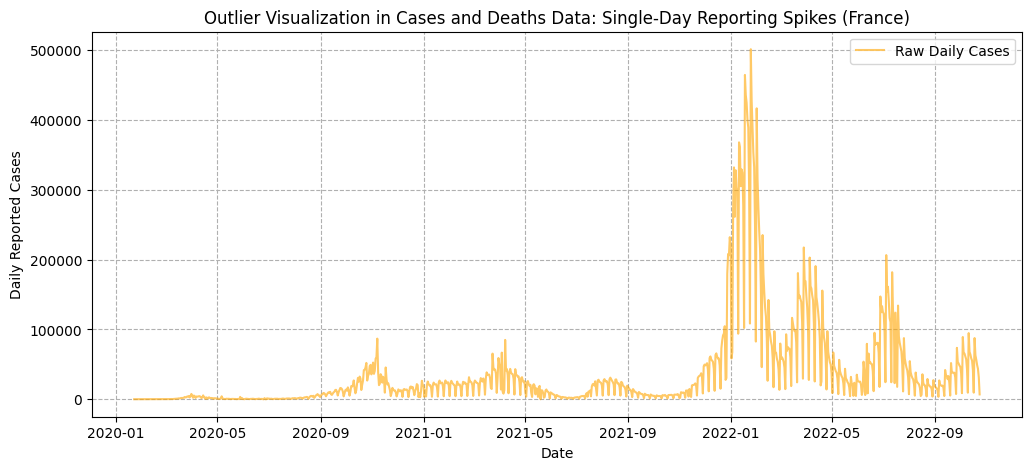

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

# Let's filter for a specific country to make the outlier spikes crystal clear
sample_country = cases_df[cases_df['countriesAndTerritories'] == 'France']

plt.figure(figsize=(12, 5))
plt.plot(sample_country['dateRep'], sample_country['cases'], label='Raw Daily Cases', color='orange', alpha=0.6)
plt.title('Outlier Visualization in Cases and Deaths Data: Single-Day Reporting Spikes (France)')
plt.xlabel('Date')
plt.ylabel('Daily Reported Cases')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()

**B. Vaccination Data**

The vacc_df dataset is heavily categorical. It doesn't track a single continuous national timeline; instead, it is grouped by country, age, vaccine brand, and is less “spiky” than the Cases and Deaths data. To show the outliers, I chose a box plot.

**Why the Boxplot is better**: A boxplot allows us to group the data by TargetGroup on the x-axis. Since different age brackets have vastly different population sizes, the boxplot establishes a unique "normal range" (the box and whiskers) for each group. Any point floating far above a specific group's whiskers reveals a week where an anomalously massive delivery or logging backlog occurred for that specific demographic.

The Problem with a Line Plot here: If you tried to plot this as a line chart, you would get a messy "spaghetti plot" with dozens of crisscrossing lines for every single age group and vaccine brand, making it impossible to read.

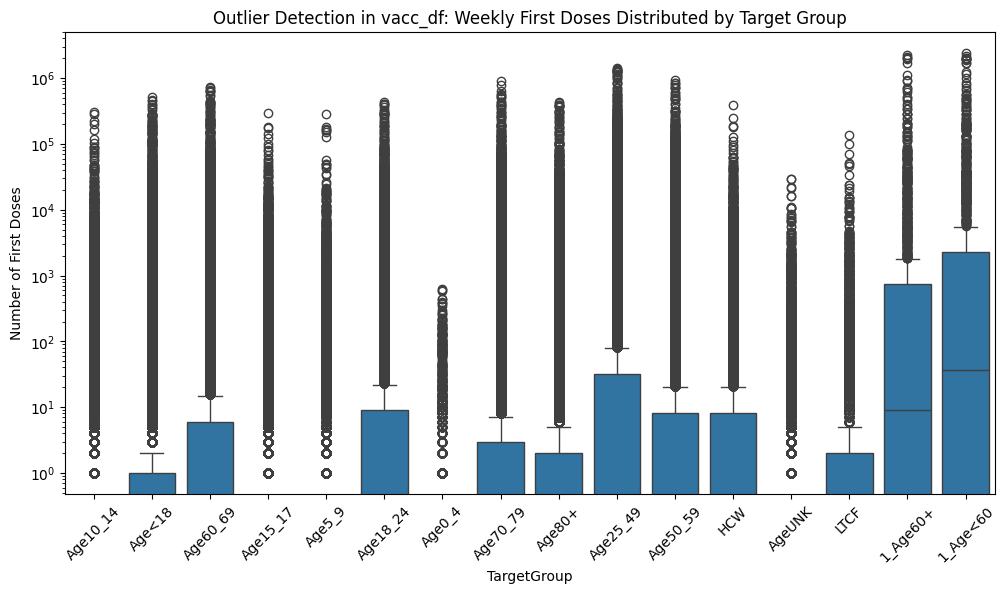

In [70]:
plt.figure(figsize=(12, 6))
# Filter out the 'ALL' group to see the distributions of specific age brackets cleanly
sns.boxplot(data=vacc_df[vacc_df['TargetGroup'] != 'ALL'], x='TargetGroup', y='FirstDose')
plt.title('Outlier Detection in vacc_df: Weekly First Doses Distributed by Target Group')
plt.xticks(rotation=45)
plt.ylabel('Number of First Doses')
plt.yscale('log') # Using a log scale helps if some groups are much larger than others
plt.show()

**C. Hospital and ICU Data**

This dataset is time-series, healthcare pressure data, and contains surges. It combines entirely different metrics (indicators) with completely different mathematical scales into the same column. For instance, it mixes Daily occupancy (the total number of people currently sitting in hospital beds today) with Weekly new admissions per 100k (a small, calculated ratio). To show the outliers, I chose a box plot.

**Why the Boxplot (with a Log Scale) is better**: By separating the x-axis by indicator, the boxplot isolates each metric's distribution. Adding a logarithmic scale allows Python to shrink the visual distance between massive numbers and tiny decimals. This lets you visually inspect both indicators simultaneously to see if any country experienced sudden, non-physical spikes in their healthcare telemetry.

The Problem with a Line Plot here: Comparing a raw daily count (e.g., 5,000 patients in beds) against a ratio per 100k (e.g., 12.5 admissions) on the same timeline chart would completely flatten the smaller ratio line, making it invisible.

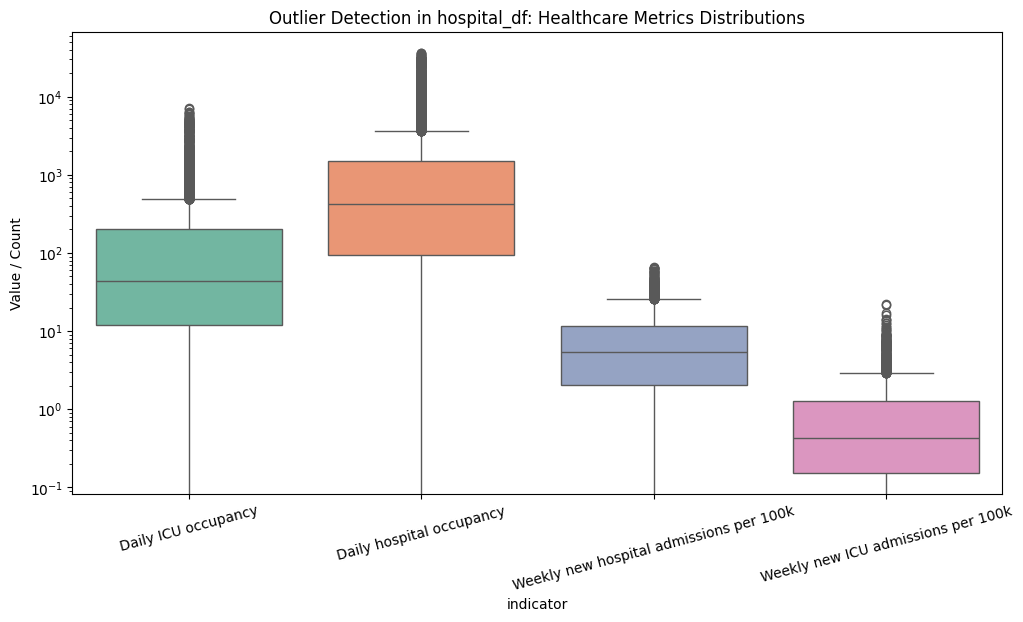

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# FIXED: Added hue='indicator' and legend=False to resolve the deprecation warning
sns.boxplot(
    data=hospital_df, 
    x='indicator', 
    y='value', 
    hue='indicator', 
    palette='Set2', 
    legend=False
)

plt.title('Outlier Detection in hospital_df: Healthcare Metrics Distributions')
plt.xticks(rotation=15)
plt.ylabel('Value / Count')
plt.yscale('log') # Log scale handles the difference between daily and weekly scales
plt.show()

# Data Transformation

Data transformation was performed to prepare the datasets for exploratory data analysis and visualization.

- Temporal variables such as year, month, and quarter were extracted from date columns to support time-based analyses.
- Population-normalized metrics, including cases and deaths per 100,000 population and vaccination rates, were calculated to enable fair comparisons between countries.
- Logarithmic transformations were additionally applied to highly skewed variables to improve interpretability.
- Finally, aggregated country-level and quarterly summaries were created to facilitate trend analysis and visualization.”

In [72]:
import pandas as pd
import numpy as np

# 1. CASES AND DEATHS DATA TRANSFORMATION
# Sort data
cases_df = cases_df.sort_values(
    by=['countriesAndTerritories', 'dateRep']
).reset_index(drop=True)

# Create time columns
cases_df['quarter'] = cases_df['dateRep'].dt.quarter
cases_df['year_quarter'] = (
    cases_df['year'].astype(str) + '-Q' + cases_df['quarter'].astype(str)
)

# Create population-normalized variables
cases_df['cases_per_100k'] = (
    cases_df['cases'] / cases_df['popData2020']
) * 100000

cases_df['deaths_per_100k'] = (
    cases_df['deaths'] / cases_df['popData2020']
) * 100000

# Optional log transformation for skewed data
cases_df['log_cases'] = np.log1p(cases_df['cases'])
cases_df['log_deaths'] = np.log1p(cases_df['deaths'])

# Create quarterly summary
quarterly_cases_df = (
    cases_df.groupby(
        ['countriesAndTerritories', 'countryterritoryCode', 'year', 'quarter', 'year_quarter'],
        as_index=False
    )
    .agg(
        total_cases=('cases', 'sum'),
        total_deaths=('deaths', 'sum'),
        population=('popData2020', 'first'),
        cases_per_100k=('cases_per_100k', 'sum'),
        deaths_per_100k=('deaths_per_100k', 'sum')
    )
)

print("Cases data transformation completed.")
print(cases_df.head())
print(quarterly_cases_df.head())

# 2. VACCINATION DATA TRANSFORMATION
# Extract year and week from YearWeekISO
vacc_df['year'] = vacc_df['YearWeekISO'].str[:4].astype(int)
vacc_df['week'] = vacc_df['YearWeekISO'].str[-2:].astype(int)

# Create a date from year-week
vacc_df['week_start_date'] = pd.to_datetime(
    vacc_df['year'].astype(str) + '-W' + vacc_df['week'].astype(str) + '-1',
    format='%G-W%V-%u'
)

# Create vaccination rate using Population
vacc_df['first_dose_rate'] = (
    vacc_df['FirstDose'] / vacc_df['Population']
) * 100

vacc_df['second_dose_rate'] = (
    vacc_df['SecondDose'] / vacc_df['Population']
) * 100

# Create refused first-dose rate
vacc_df['first_dose_refused_rate'] = (
    vacc_df['FirstDoseRefused'] / vacc_df['Population']
) * 100

# Optional log transformation
vacc_df['log_first_dose'] = np.log1p(vacc_df['FirstDose'])
vacc_df['log_second_dose'] = np.log1p(vacc_df['SecondDose'])

# Summary by country and vaccine
vacc_country_vaccine_df = (
    vacc_df.groupby(['ReportingCountry', 'Vaccine'], as_index=False)
    .agg(
        total_first_dose=('FirstDose', 'sum'),
        total_second_dose=('SecondDose', 'sum'),
        total_doses_received=('NumberDosesReceived', 'sum'),
        total_doses_exported=('NumberDosesExported', 'sum'),
        total_first_dose_refused=('FirstDoseRefused', 'sum'),
        population=('Population', 'first')
    )
)

# Add rates to summary
vacc_country_vaccine_df['first_dose_rate'] = (
    vacc_country_vaccine_df['total_first_dose'] /
    vacc_country_vaccine_df['population']
) * 100

vacc_country_vaccine_df['second_dose_rate'] = (
    vacc_country_vaccine_df['total_second_dose'] /
    vacc_country_vaccine_df['population']
) * 100

# Summary by country and target group
vacc_target_group_df = (
    vacc_df.groupby(['ReportingCountry', 'TargetGroup', 'Vaccine'], as_index=False)
    .agg(
        total_first_dose=('FirstDose', 'sum'),
        total_second_dose=('SecondDose', 'sum'),
        population=('Population', 'first')
    )
)

print("Vaccination data transformation completed.")
print(vacc_df.head())
print(vacc_country_vaccine_df.head())
print(vacc_target_group_df.head())

# 3. HOSPITAL AND ICU DATA TRANSFORMATION
# Make sure date is datetime
hospital_df['date'] = pd.to_datetime(hospital_df['date'], format='%Y-%m-%d')

# Sort data
hospital_df = hospital_df.sort_values(
    by=['country', 'indicator', 'date']
).reset_index(drop=True)

# Create time columns
hospital_df['year'] = hospital_df['date'].dt.year
hospital_df['quarter'] = hospital_df['date'].dt.quarter
hospital_df['year_quarter'] = (
    hospital_df['year'].astype(str) + '-Q' + hospital_df['quarter'].astype(str)
)

# Optional log transformation
hospital_df['log_value'] = np.log1p(hospital_df['value'])

# Yearly hospital/ICU summary
hospital_yearly_df = (
    hospital_df.groupby(['country', 'indicator', 'year'], as_index=False)
    .agg(
        mean_value=('value', 'mean'),
        max_value=('value', 'max'),
        total_value=('value', 'sum')
    )
)

# Quarterly hospital/ICU summary
hospital_quarterly_df = (
    hospital_df.groupby(['country', 'indicator', 'year', 'quarter', 'year_quarter'], as_index=False)
    .agg(
        mean_value=('value', 'mean'),
        max_value=('value', 'max'),
        total_value=('value', 'sum')
    )
)

print("Hospital data transformation completed.")
print(hospital_df.head())
print(hospital_yearly_df.head())
print(hospital_quarterly_df.head())

Cases data transformation completed.
     dateRep  day  month  year  cases  deaths countriesAndTerritories geoId  \
0 2020-02-26   26      2  2020    1.0     0.0                 Austria    AT   
1 2020-02-27   27      2  2020    2.0     0.0                 Austria    AT   
2 2020-02-28   28      2  2020    4.0     0.0                 Austria    AT   
3 2020-02-29   29      2  2020    1.0     0.0                 Austria    AT   
4 2020-03-01    1      3  2020    4.0     0.0                 Austria    AT   

  countryterritoryCode  popData2020 continentExp  quarter year_quarter  \
0                  AUT      8901064       Europe        1      2020-Q1   
1                  AUT      8901064       Europe        1      2020-Q1   
2                  AUT      8901064       Europe        1      2020-Q1   
3                  AUT      8901064       Europe        1      2020-Q1   
4                  AUT      8901064       Europe        1      2020-Q1   

   cases_per_100k  deaths_per_100k  log_cas

# Exploratory Data Analysis (EDA)

In this section, exploratory data analysis is performed to understand the main patterns in the three datasets. The analysis includes distribution plots, country comparisons, time-series trends, and healthcare burden visualizations. These results help identify important patterns before answering the mandatory assignment questions.

**A. Cases and Deaths Data**

=== Cases and Deaths Summary ===
               cases        deaths  cases_per_100k  deaths_per_100k
count   28729.000000  28729.000000    28729.000000     28729.000000
mean     6081.468133     40.461380       42.411822         0.266741
std     21321.256960    128.129124       94.196757         0.919464
min         0.000000      0.000000        0.000000         0.000000
25%       108.000000      0.000000        2.526411         0.000000
50%       698.000000      5.000000       13.020732         0.078108
75%      3466.000000     30.000000       40.840212         0.319434
max    501635.000000  13743.000000     3785.419653       128.216790


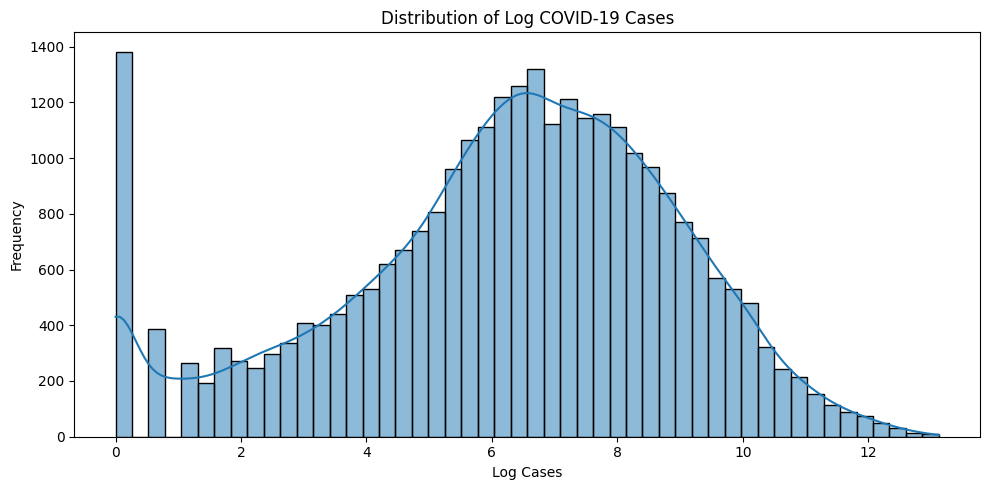

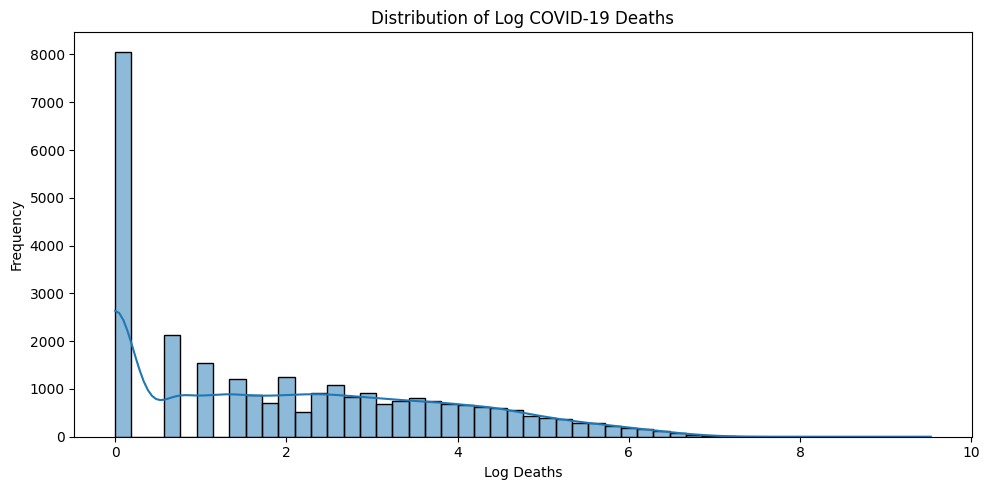

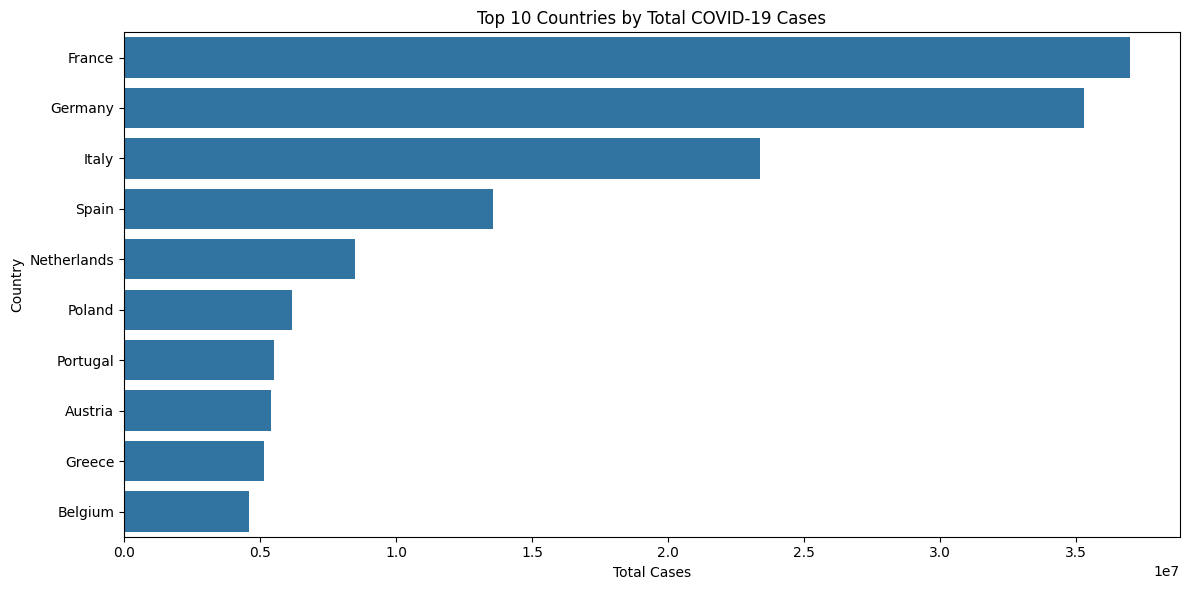

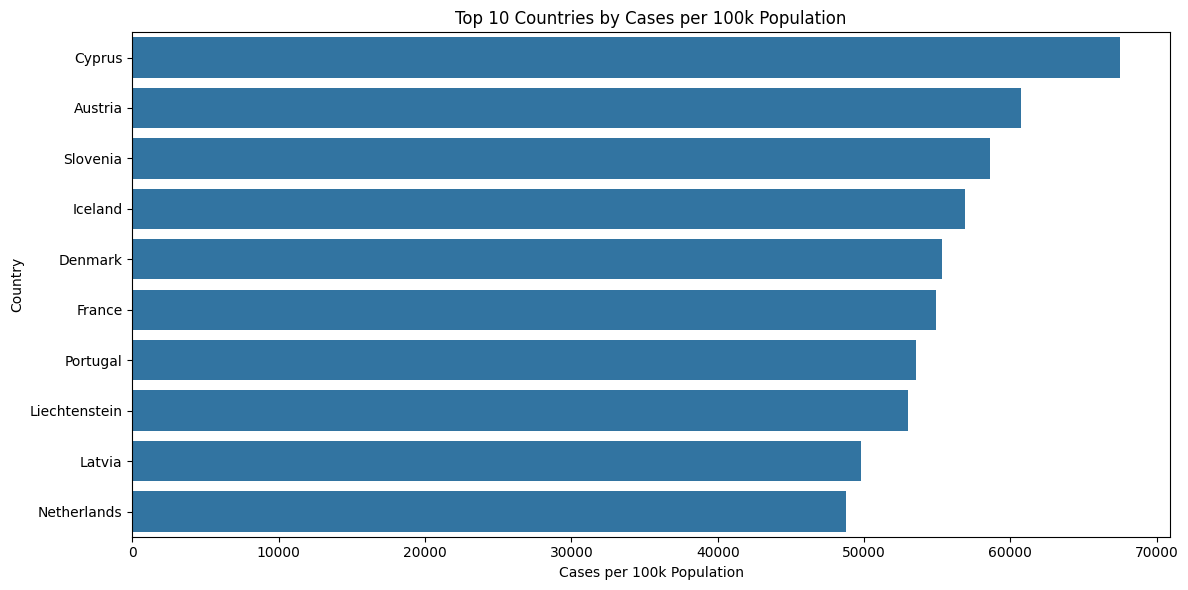

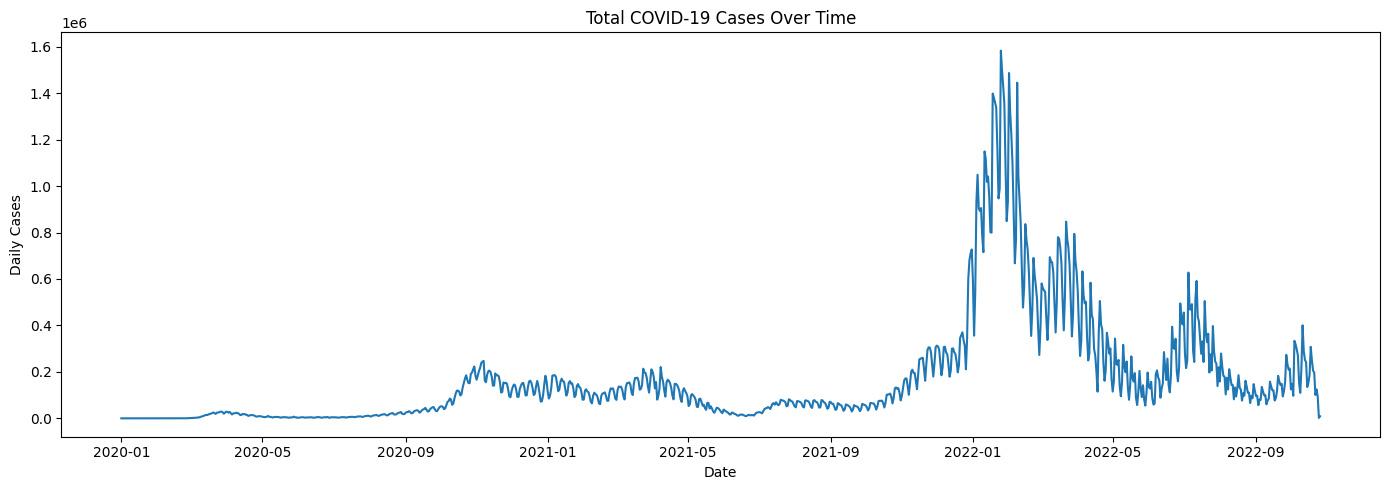

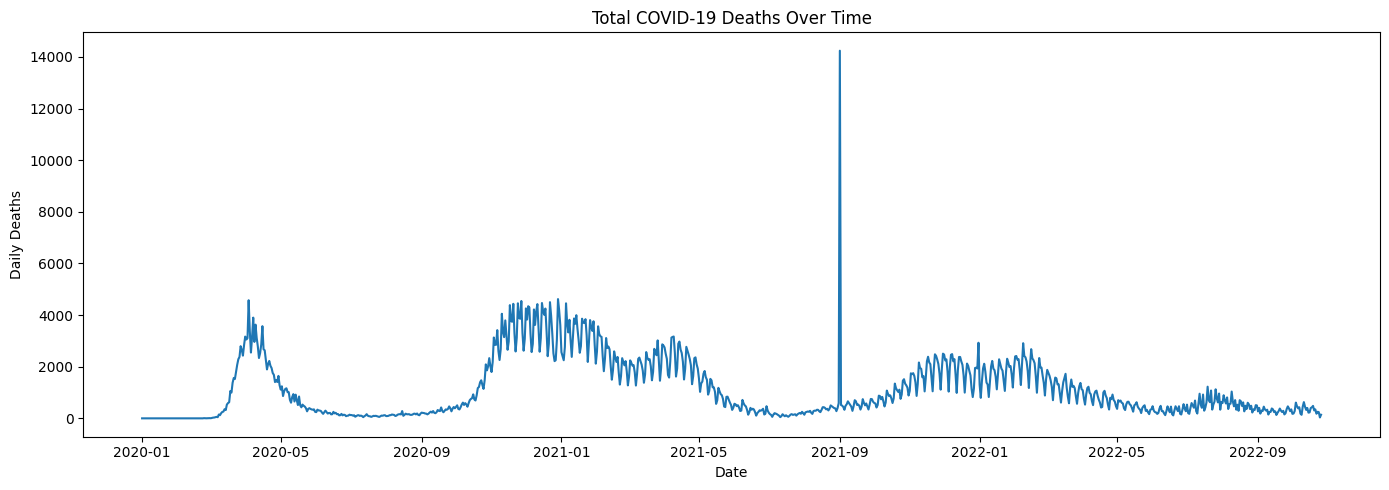

In [73]:
# 1. Basic statistical summary
print("=== Cases and Deaths Summary ===")
print(cases_df[['cases', 'deaths', 'cases_per_100k', 'deaths_per_100k']].describe())


# 2. Distribution of COVID-19 cases
plt.figure(figsize=(10, 5))

sns.histplot(
    data=cases_df,
    x='log_cases',
    bins=50,
    kde=True
)

plt.title("Distribution of Log COVID-19 Cases")
plt.xlabel("Log Cases")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# 3. Distribution of COVID-19 deaths
plt.figure(figsize=(10, 5))

sns.histplot(
    data=cases_df,
    x='log_deaths',
    bins=50,
    kde=True
)

plt.title("Distribution of Log COVID-19 Deaths")
plt.xlabel("Log Deaths")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# 4. Top 10 countries by total cases
top10_cases = (
    cases_df.groupby('countriesAndTerritories')['cases']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top10_cases.values,
    y=top10_cases.index
)

plt.title("Top 10 Countries by Total COVID-19 Cases")
plt.xlabel("Total Cases")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

# 5. Top 10 countries by cases per 100k population
top10_cases_100k = (
    cases_df.groupby('countriesAndTerritories')['cases_per_100k']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top10_cases_100k.values,
    y=top10_cases_100k.index
)

plt.title("Top 10 Countries by Cases per 100k Population")
plt.xlabel("Cases per 100k Population")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

# 6. Total COVID-19 cases over time
daily_cases = (
    cases_df.groupby('dateRep')['cases']
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 5))

sns.lineplot(
    data=daily_cases,
    x='dateRep',
    y='cases'
)

plt.title("Total COVID-19 Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Daily Cases")
plt.tight_layout()
plt.show()

# 7. Total COVID-19 deaths over time
daily_deaths = (
    cases_df.groupby('dateRep')['deaths']
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 5))

sns.lineplot(
    data=daily_deaths,
    x='dateRep',
    y='deaths'
)

plt.title("Total COVID-19 Deaths Over Time")
plt.xlabel("Date")
plt.ylabel("Daily Deaths")
plt.tight_layout()
plt.show()

**B. Vaccination Data**

Countries without matched names:
[]
=== Country-level Vaccination Summary ===
       total_first_dose  total_second_dose  total_first_dose_refused  \
count      3.000000e+01       3.000000e+01                 30.000000   
mean       3.110852e+07       2.831494e+07                 19.366667   
std        5.113984e+07       4.764124e+07                106.075602   
min        5.178200e+04       5.079000e+04                  0.000000   
25%        3.128370e+06       2.371351e+06                  0.000000   
50%        1.100347e+07       1.050212e+07                  0.000000   
75%        2.477683e+07       2.169037e+07                  0.000000   
max        2.140703e+08       2.043717e+08                581.000000   

         population  first_dose_rate  second_dose_rate  \
count  3.000000e+01        30.000000         30.000000   
mean   1.508391e+07       177.352537        159.673020   
std    2.156276e+07        79.848710         76.811256   
min    3.930800e+04        61.628445     

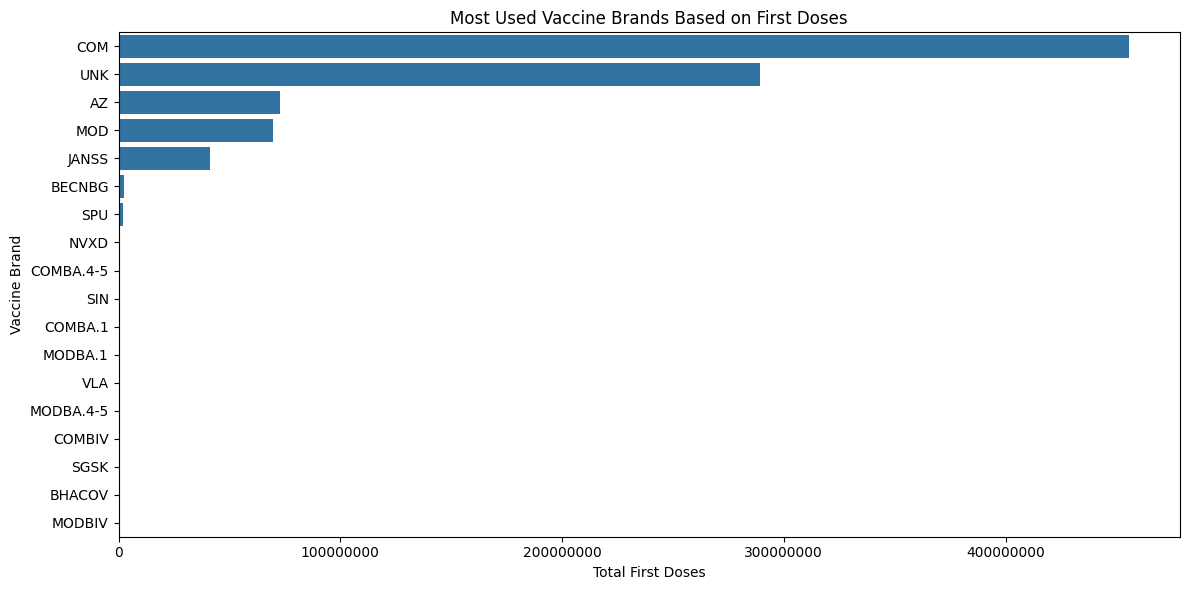

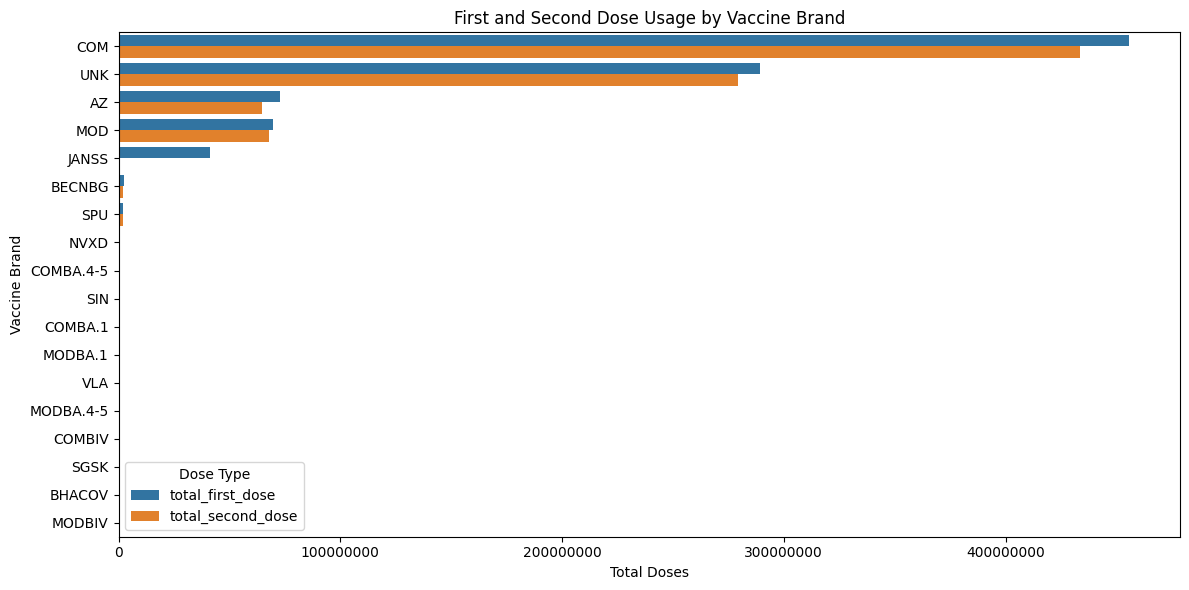

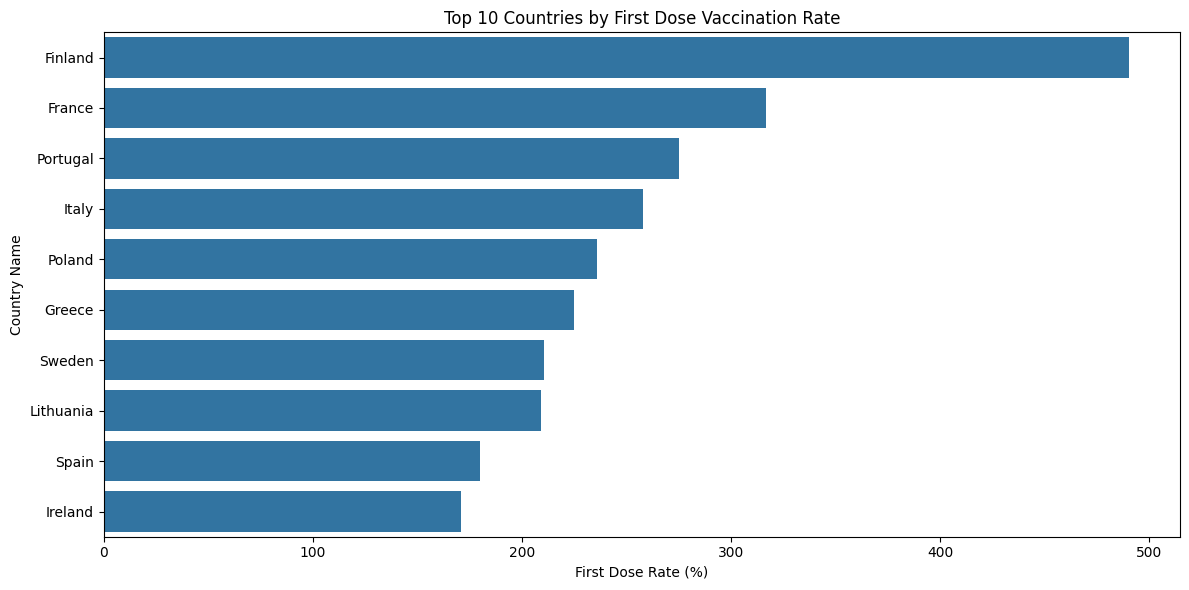

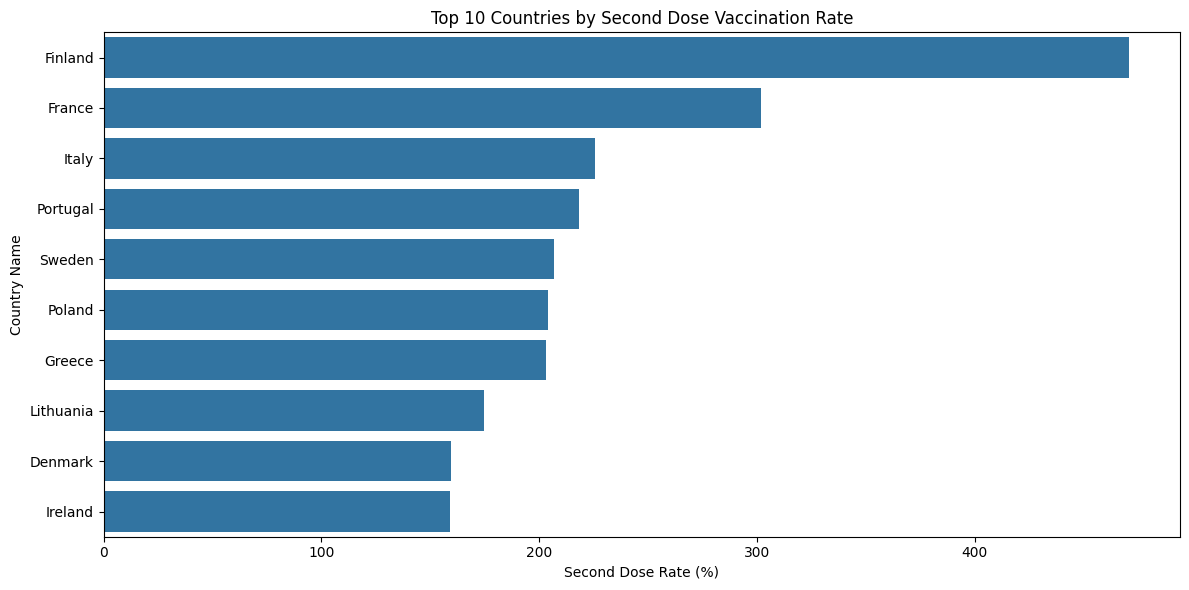

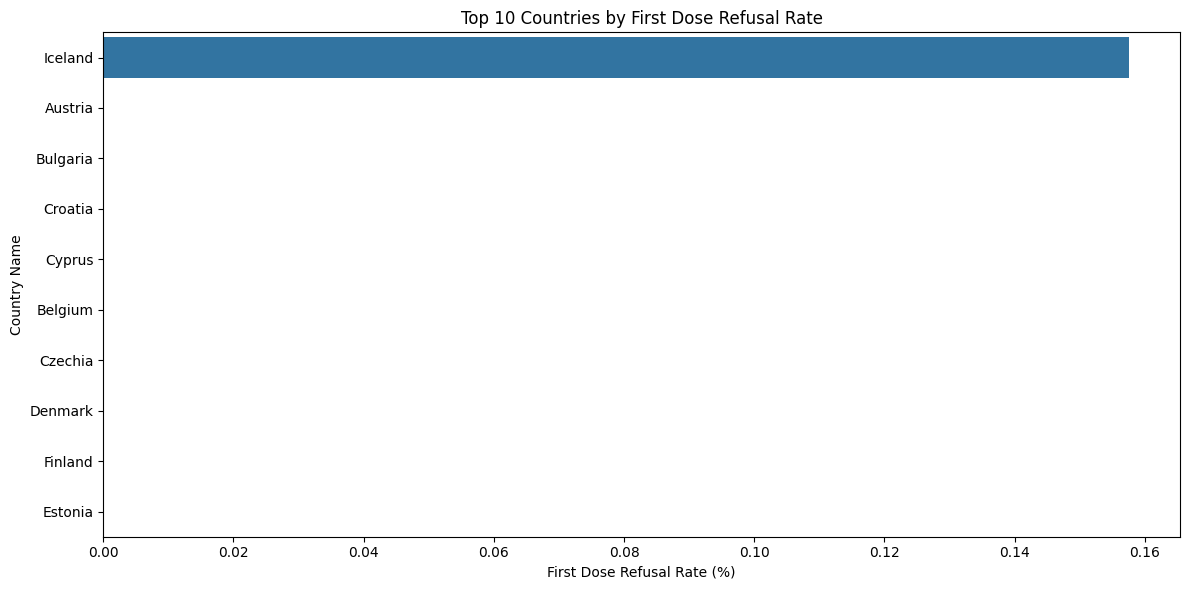

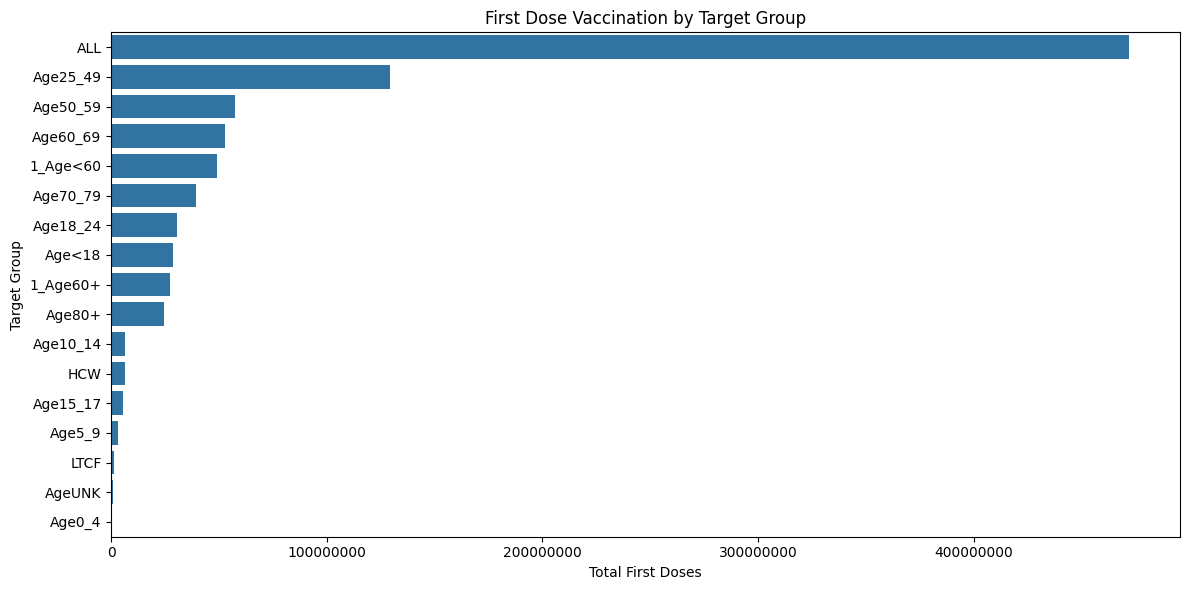

In [74]:
# 1. Add full country names to vaccination dataset
country_lookup = (
    cases_df[['geoId', 'countriesAndTerritories']]
    .drop_duplicates()
    .rename(columns={
        'geoId': 'ReportingCountry',
        'countriesAndTerritories': 'country_name'
    })
)

vacc_df = vacc_df.drop(columns=['country_name'], errors='ignore')

vacc_df = vacc_df.merge(
    country_lookup,
    on='ReportingCountry',
    how='left'
)

print("Countries without matched names:")
print(vacc_df[vacc_df['country_name'].isnull()]['ReportingCountry'].unique())

# 2. Country-level vaccination summary
country_vacc_summary = (
    vacc_df.groupby('country_name')
    .agg(
        total_first_dose=('FirstDose', 'sum'),
        total_second_dose=('SecondDose', 'sum'),
        total_first_dose_refused=('FirstDoseRefused', 'sum'),
        population=('Population', 'first')
    )
    .reset_index()
)

country_vacc_summary['first_dose_rate'] = (
    country_vacc_summary['total_first_dose'] /
    country_vacc_summary['population']
) * 100

country_vacc_summary['second_dose_rate'] = (
    country_vacc_summary['total_second_dose'] /
    country_vacc_summary['population']
) * 100

country_vacc_summary['first_dose_refused_rate'] = (
    country_vacc_summary['total_first_dose_refused'] /
    country_vacc_summary['population']
) * 100

print("=== Country-level Vaccination Summary ===")
print(country_vacc_summary.describe())

# 3. Most used vaccine brands
vaccine_usage = (
    vacc_df.groupby('Vaccine')
    .agg(
        total_first_dose=('FirstDose', 'sum'),
        total_second_dose=('SecondDose', 'sum')
    )
    .reset_index()
    .sort_values('total_first_dose', ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=vaccine_usage,
    x='total_first_dose',
    y='Vaccine'
)

plt.title("Most Used Vaccine Brands Based on First Doses")
plt.xlabel("Total First Doses")
plt.ylabel("Vaccine Brand")
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

# 4. First dose vs second dose by vaccine brand
vaccine_usage_long = vaccine_usage.melt(
    id_vars='Vaccine',
    value_vars=['total_first_dose', 'total_second_dose'],
    var_name='Dose Type',
    value_name='Total Doses'
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=vaccine_usage_long,
    x='Total Doses',
    y='Vaccine',
    hue='Dose Type'
)

plt.title("First and Second Dose Usage by Vaccine Brand")
plt.xlabel("Total Doses")
plt.ylabel("Vaccine Brand")
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

# 5. Top 10 countries by first dose vaccination rate
top_first_dose_rate = (
    country_vacc_summary
    .sort_values('first_dose_rate', ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_first_dose_rate,
    x='first_dose_rate',
    y='country_name'
)

plt.title("Top 10 Countries by First Dose Vaccination Rate")
plt.xlabel("First Dose Rate (%)")
plt.ylabel("Country Name")
plt.tight_layout()
plt.show()

# 6. Top 10 countries by second dose vaccination rate
top_second_dose_rate = (
    country_vacc_summary
    .sort_values('second_dose_rate', ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_second_dose_rate,
    x='second_dose_rate',
    y='country_name'
)

plt.title("Top 10 Countries by Second Dose Vaccination Rate")
plt.xlabel("Second Dose Rate (%)")
plt.ylabel("Country Name")
plt.tight_layout()
plt.show()

# 8. Top 10 countries by first dose refusal rate
top_refusal_rate = (
    country_vacc_summary
    .sort_values('first_dose_refused_rate', ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_refusal_rate,
    x='first_dose_refused_rate',
    y='country_name'
)

plt.title("Top 10 Countries by First Dose Refusal Rate")
plt.xlabel("First Dose Refusal Rate (%)")
plt.ylabel("Country Name")
plt.tight_layout()
plt.show()

# 9. Vaccination by target group
target_group_summary = (
    vacc_df.groupby('TargetGroup')
    .agg(
        total_first_dose=('FirstDose', 'sum'),
        total_second_dose=('SecondDose', 'sum')
    )
    .reset_index()
    .sort_values('total_first_dose', ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=target_group_summary,
    x='total_first_dose',
    y='TargetGroup'
)

plt.title("First Dose Vaccination by Target Group")
plt.xlabel("Total First Doses")
plt.ylabel("Target Group")
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

**C. Hospital Data**

=== Hospital and ICU Summary ===
              value     log_value
count  25100.000000  25100.000000
mean     818.736440      4.215197
std     2540.068028      2.513499
min        0.000000      0.000000
25%        8.000000      2.197225
50%       70.000000      4.262680
75%      514.000000      6.244167
max    36403.000000     10.502434


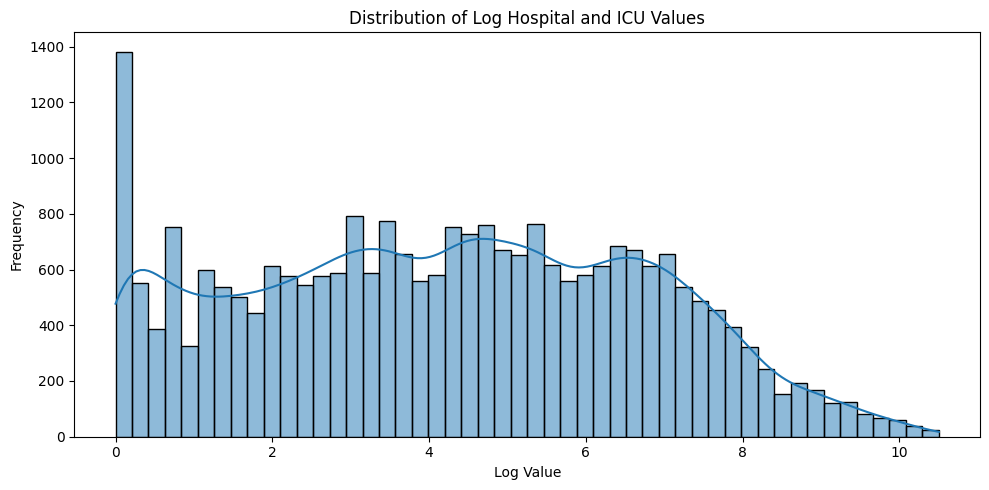

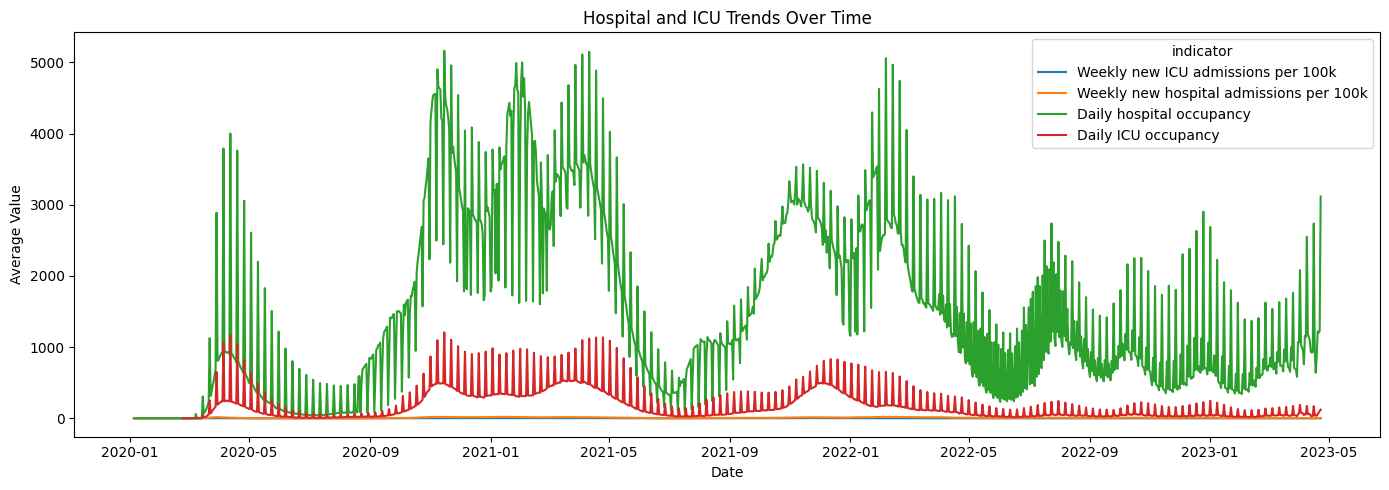

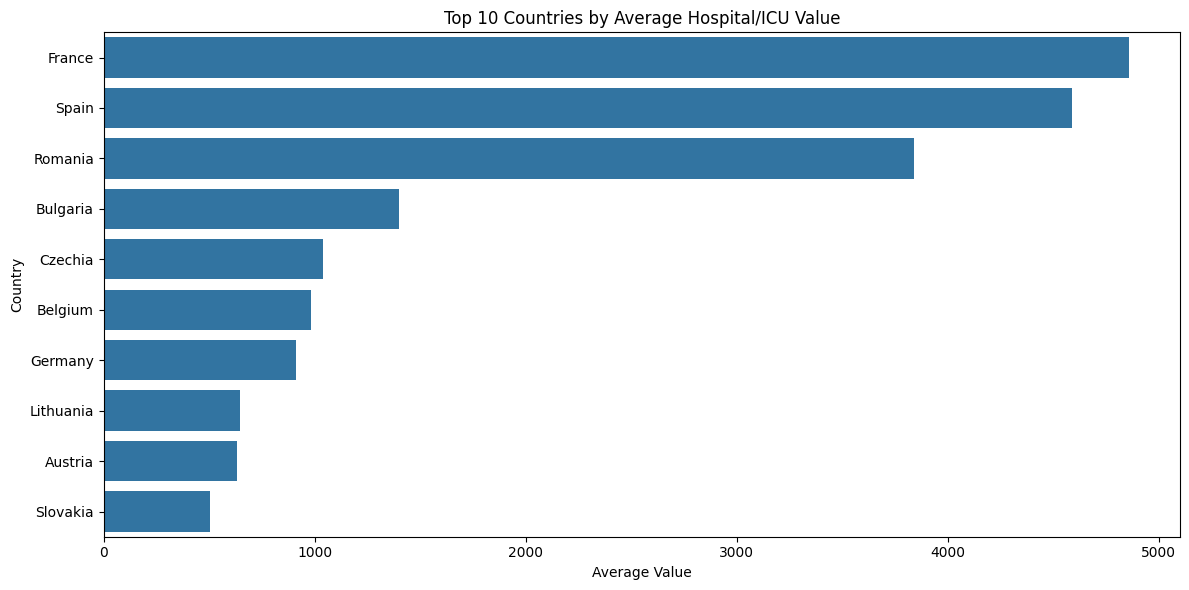

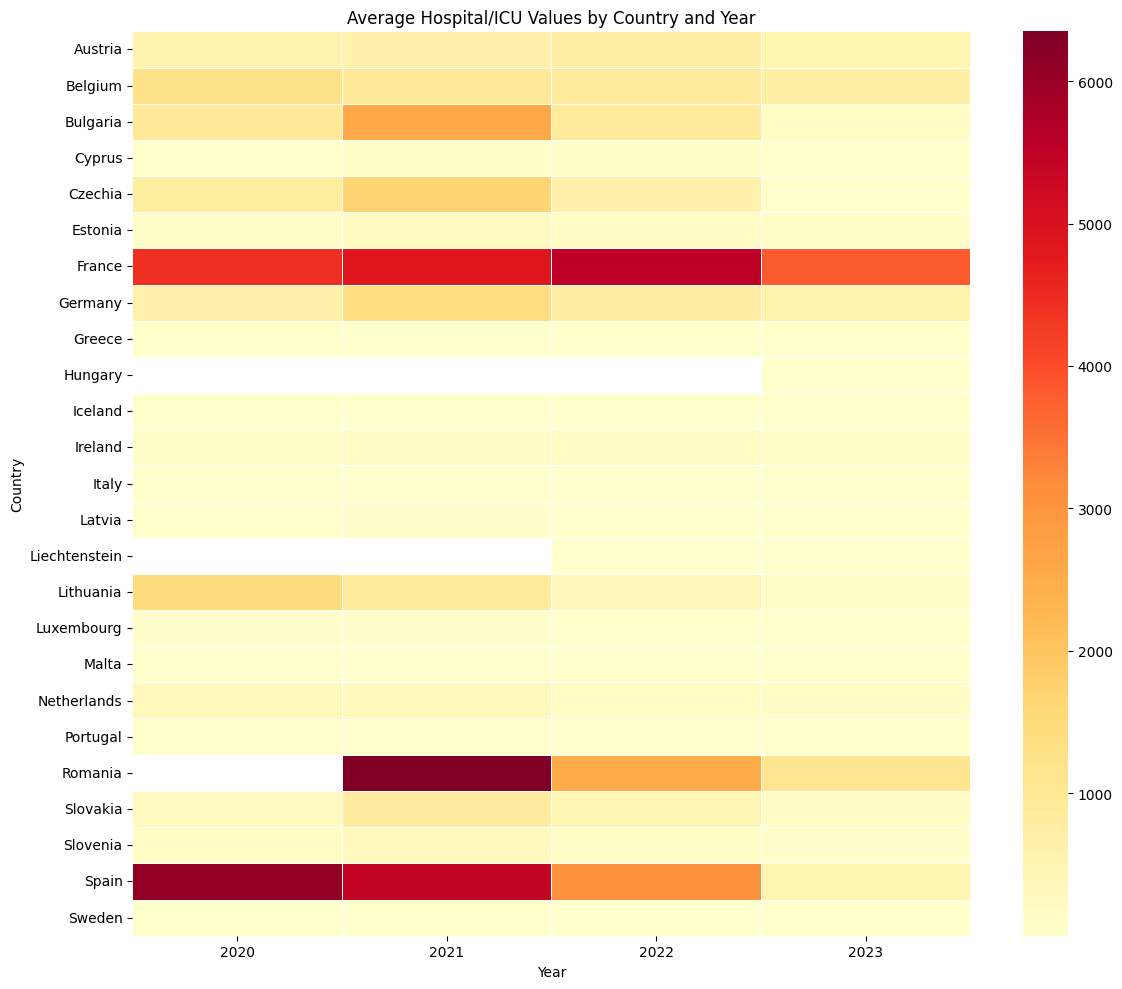

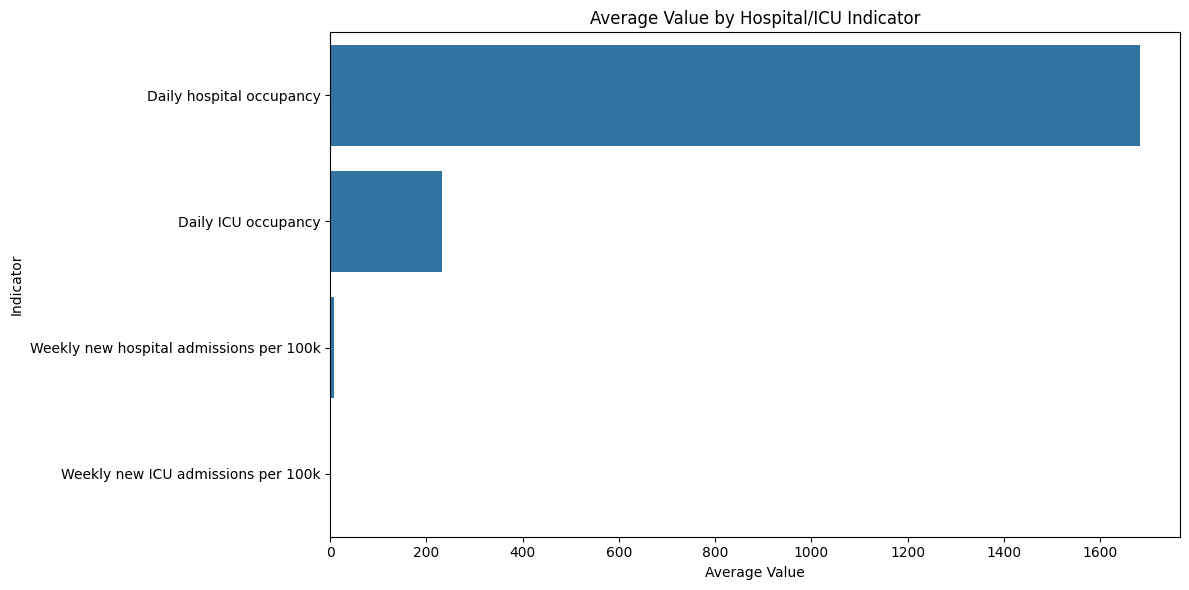

In [75]:
# 1. Basic statistical summary
print("=== Hospital and ICU Summary ===")
print(hospital_df[['value', 'log_value']].describe())

# 2. Distribution of hospital and ICU values
plt.figure(figsize=(10, 5))

sns.histplot(
    data=hospital_df,
    x='log_value',
    bins=50,
    kde=True
)

plt.title("Distribution of Log Hospital and ICU Values")
plt.xlabel("Log Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 3. Hospital and ICU trends over time
hospital_trend = (
    hospital_df.groupby(['date', 'indicator'])['value']
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 5))

sns.lineplot(
    data=hospital_trend,
    x='date',
    y='value',
    hue='indicator'
)

plt.title("Hospital and ICU Trends Over Time")
plt.xlabel("Date")
plt.ylabel("Average Value")
plt.tight_layout()
plt.show()

# 4. Top 10 countries by average hospital/ICU value
top_hospital_countries = (
    hospital_df.groupby('country')['value']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_hospital_countries.values,
    y=top_hospital_countries.index
)

plt.title("Top 10 Countries by Average Hospital/ICU Value")
plt.xlabel("Average Value")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

# 5. Average hospital/ICU values by country and year
hospital_heatmap = hospital_df.pivot_table(
    values='value',
    index='country',
    columns='year',
    aggfunc='mean'
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    hospital_heatmap,
    cmap='YlOrRd',
    linewidths=0.5
)

plt.title("Average Hospital/ICU Values by Country and Year")
plt.xlabel("Year")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

# 6. Average value by indicator
indicator_avg = (
    hospital_df.groupby('indicator')['value']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=indicator_avg.values,
    y=indicator_avg.index
)

plt.title("Average Value by Hospital/ICU Indicator")
plt.xlabel("Average Value")
plt.ylabel("Indicator")
plt.tight_layout()
plt.show()

# COVID-19 Cases and Death Analysis (Cases and Death Data)
## Q1.1: Top countries with the highest cases by quarter.

Top 10 countries by total COVID-19 cases:
countriesAndTerritories
France         36962242.0
Germany        35287690.0
Italy          23359828.0
Spain          13564823.0
Netherlands     8494705.0
Poland          6189562.0
Portugal        5514482.0
Austria         5402162.0
Greece          5138059.0
Belgium         4607296.0
Name: total_cases, dtype: float64
--- QUARTERLY COVID-19 MATRIX ---


year_quarter,2020-Q1,2020-Q2,2020-Q3,2020-Q4,2021-Q1,2021-Q2,2021-Q3,2021-Q4,2022-Q1,2022-Q2,2022-Q3,2022-Q4,Total Cases
Country,,,,,,,,,,,,,
France,52.131,113.439,398.734,2.056.890,2.023.998,1.479.724,1.238.131,2.959.368,15.642.043,5.474.911,4.307.356,1.215.517,36.962.242
Germany,74.061,120.893,98.995,1.460.483,1.085.469,888.207,514.274,2.952.749,14.337.869,6.830.657,5.058.149,1.865.884,35.287.690
Italy,105.792,134.934,74.283,1.792.305,1.476.278,676.465,412.446,1.453.328,8.516.671,3.880.757,3.944.167,892.402,23.359.828
Spain,167.645,93.346,575.532,1.180.775,1.325.289,535.698,1.114.164,1.838.335,4.762.082,1.175.098,731.828,65.031,13.564.823
Netherlands,12.449,37.598,70.530,674.961,476.152,412.910,318.118,1.128.856,4.727.250,325.309,246.712,63.860,8.494.705
Poland,2.311,32.082,57.121,1.203.364,1.026.839,558.195,27.159,1.201.144,1.770.193,47.187,229.187,34.780,6.189.562
Portugal,7.251,35.673,34.439,323.243,406.514,66.331,198.724,342.251,2.336.007,1.427.465,304.946,31.638,5.514.482
Austria,7.312,7.253,28.065,314.780,182.007,101.655,95.232,535.893,2.599.732,586.570,682.264,261.399,5.402.162
Greece,1.314,2.095,15.066,120.375,127.698,158.767,233.311,555.086,1.819.576,646.073,1.243.690,215.008,5.138.059


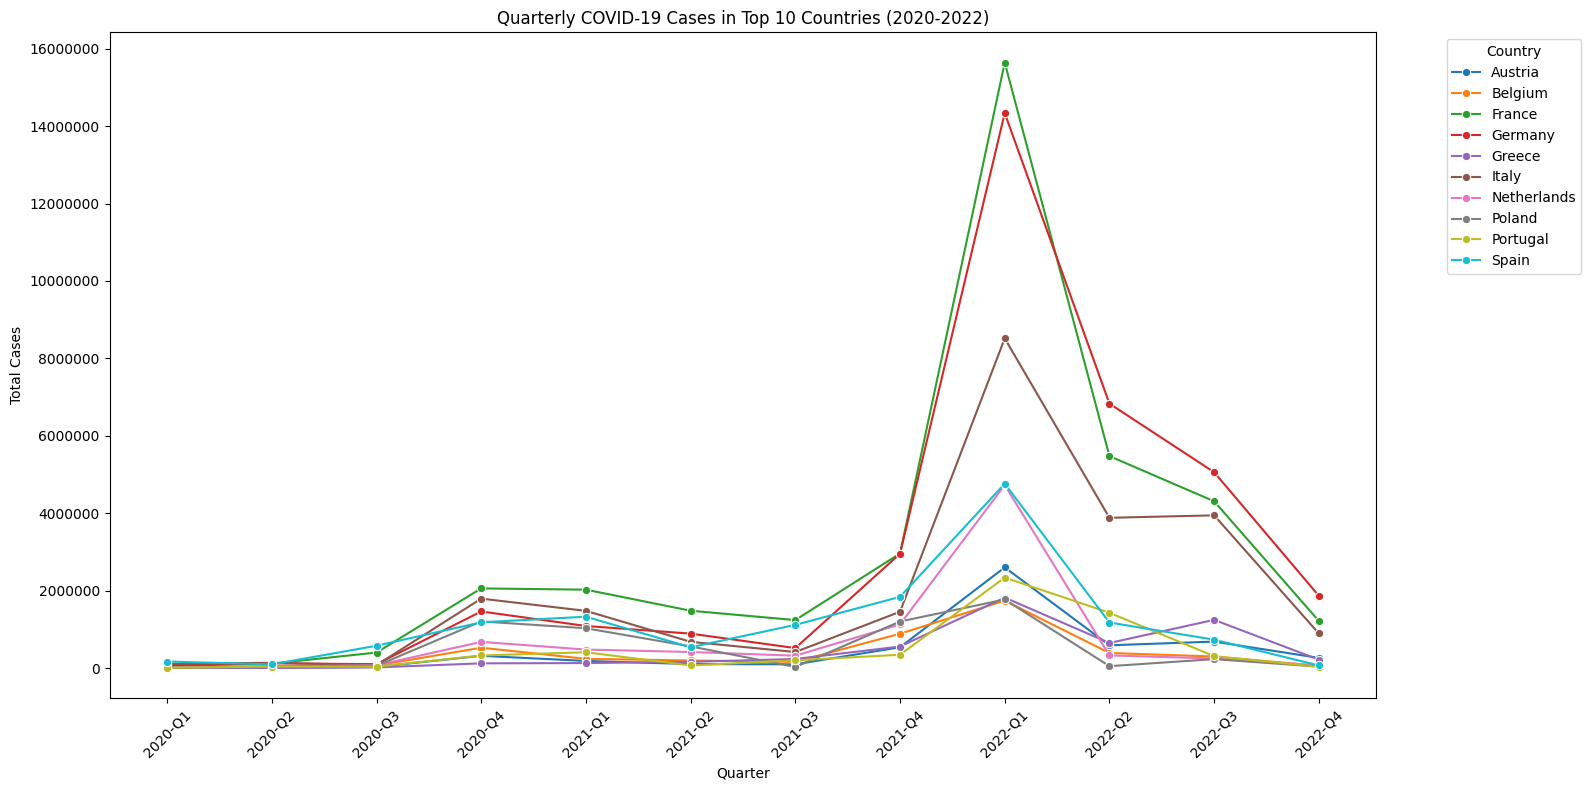

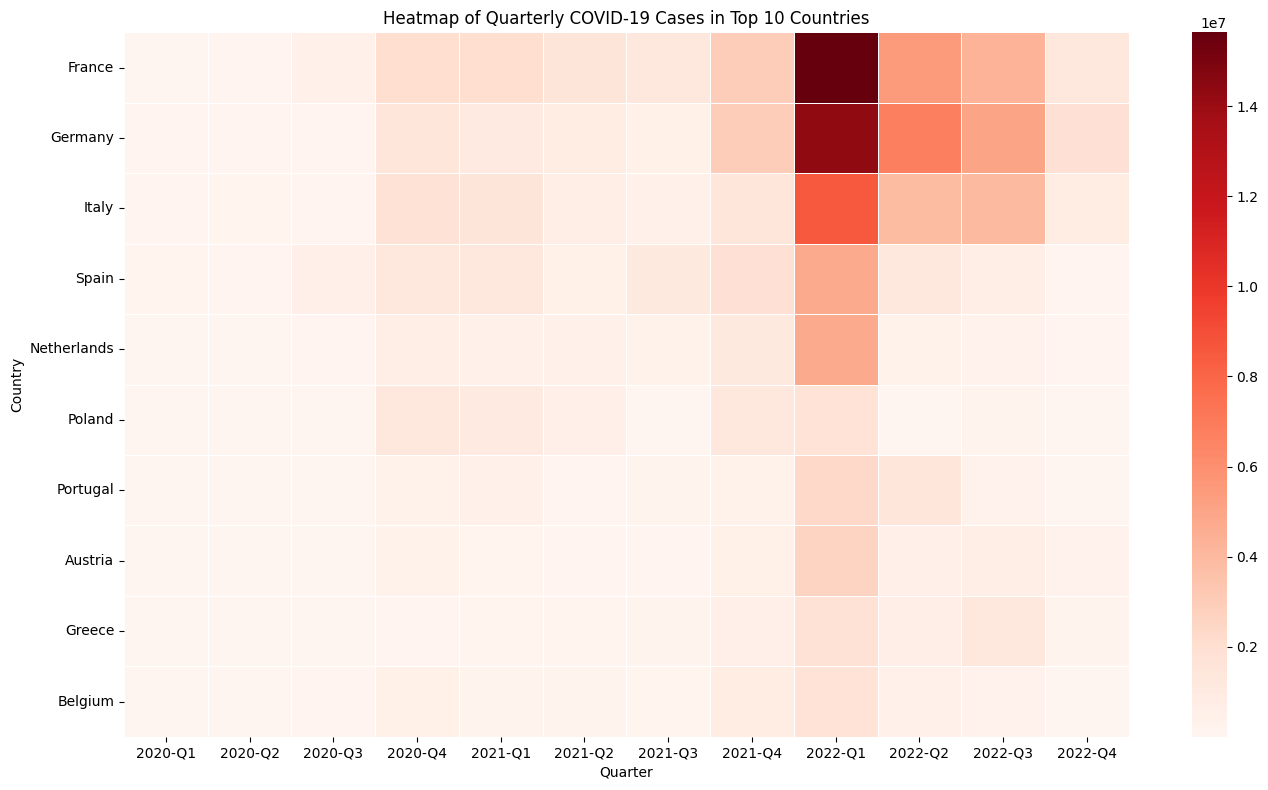

In [76]:
# 1. Filter years 2020-2022
q1_df = cases_df[
    cases_df['year'].isin([2020, 2021, 2022])
].copy()

# 2. Aggregate quarterly cases by country
quarterly_cases = (
    q1_df.groupby(
        ['countriesAndTerritories', 'year', 'quarter'],
        as_index=False
    )
    .agg(
        total_cases=('cases', 'sum'),
        population=('popData2020', 'first')
    )
)

# Create cases per 100k population
quarterly_cases['cases_per_100k'] = (
    quarterly_cases['total_cases'] /
    quarterly_cases['population']
) * 100000

# Create quarter label
quarterly_cases['year_quarter'] = (
    quarterly_cases['year'].astype(str)
    + '-Q'
    + quarterly_cases['quarter'].astype(str)
)

# 3. Filter only top 10 countries
# Find top 10 countries by total cases
top10_countries = (
    quarterly_cases.groupby('countriesAndTerritories')['total_cases']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 countries by total COVID-19 cases:")
print(top10_countries)

top10_data = quarterly_cases[
    quarterly_cases['countriesAndTerritories'].isin(top10_countries.index)
].copy()

# 4. Quarterly Matrix Table (Sorted by Total Cases with Dynamic Bolding)
# Step A: Create the pivot table with quarters as columns
q1_matrix = top10_data.pivot_table(
    values='total_cases',
    index='countriesAndTerritories',
    columns='year_quarter',
    aggfunc='sum',
    fill_value=0
)

# Step B: Calculate the absolute grand total across all quarters for sorting
q1_matrix['Total Cases'] = q1_matrix.sum(axis=1)

# Step C: Sort the rows by 'Total Cases' from highest to lowest
q1_matrix_sorted = q1_matrix.sort_values(by='Total Cases', ascending=False)

# Step D: Clean the index label for professional English presentation
q1_matrix_sorted.index.name = 'Country'

# Step E: Initialize the Pandas Styler
styled_table = q1_matrix_sorted.style

# Step F: Apply bolding to the HIGHEST value of each individual quarter column
# We slice using subset to exclude the 'Total Cases' column from being bolded
quarter_columns = [col for col in q1_matrix_sorted.columns if col != 'Total Cases']
styled_table = styled_table.highlight_max(
    subset=quarter_columns, 
    axis=0, 
    props='font-weight: bold; color: #000000;'
)

# Step G: Apply professional formatting using dots as thousands separators
styled_table = styled_table.format(lambda x: f"{int(round(x)):,}".replace(",", "."))

# Display the finalized bolded report table
print("--- QUARTERLY COVID-19 MATRIX ---")
display(styled_table)

# 5. Quarterly cases trend line plot
# To visualize quarterly COVID-19 case trends among the top 10 countries
plt.figure(figsize=(16, 8))

sns.lineplot(
    data=top10_data,
    x='year_quarter',
    y='total_cases',
    hue='countriesAndTerritories',
    marker='o'
)

plt.title("Quarterly COVID-19 Cases in Top 10 Countries (2020-2022)")
plt.xlabel("Quarter")
plt.ylabel("Total Cases")

plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')

plt.legend(
    title='Country',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

# 5. Heatmap of quarterly cases
# To visualize which quarters had the highest COVID-19 case levels for each country
heatmap_data = top10_data.pivot_table(
    values='total_cases',
    index='countriesAndTerritories',
    columns='year_quarter',
    aggfunc='sum',
    fill_value=0
)

# Reorder rows based on total cases ranking
heatmap_data = heatmap_data.loc[top10_countries.index]

plt.figure(figsize=(14, 8))

sns.heatmap(
    heatmap_data,
    cmap='Reds',
    linewidths=0.5,
    annot=False
)

plt.title("Heatmap of Quarterly COVID-19 Cases in Top 10 Countries")
plt.xlabel("Quarter")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

**Observation**:
- The line chart shows several distinct waves of COVID-19 cases across the top 10 countries between 2020 and 2022.
- Case numbers generally increased over time, with the highest peaks occurring during 2021 and 2022.
- Many countries experienced similar timing of peaks, suggesting that pandemic waves occurred across Europe during similar periods.

- The heatmap highlights substantial variation in case levels between quarters and countries.
- Some countries consistently reported higher case numbers than others throughout the study period.
- The darkest heatmap cells are concentrated in later quarters, indicating that the largest outbreaks occurred during the later stages of the pandemic.
- Despite differences in magnitude, most countries showed recurring increases and decreases in cases, reflecting multiple pandemic waves.

Overall, the analysis indicates that COVID-19 case levels varied considerably across countries and time periods, but most heavily affected countries experienced major infection waves during 2021 and 2022, with several countries showing synchronized patterns of increasing and decreasing case numbers

## Q1.2: The relation between the high number of cases and the country’s population.

Correlation between population and total cases: 0.923


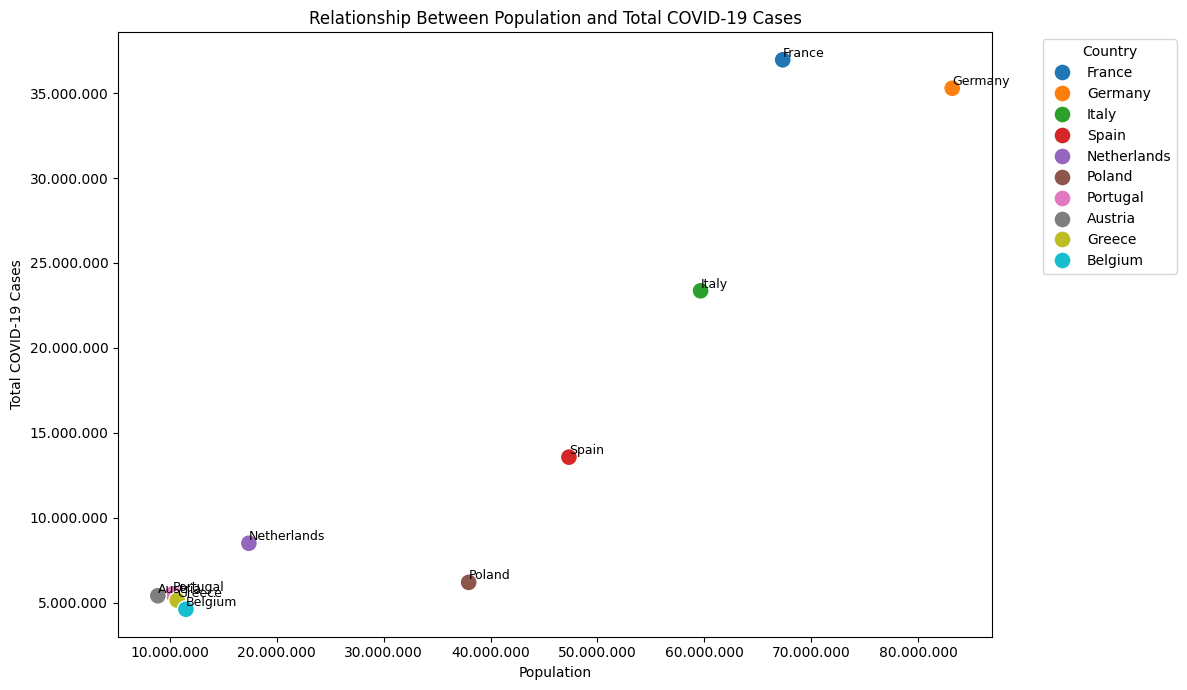

In [77]:
import matplotlib.ticker as mticker

# Relationship between population and total cases
# Aggregate total cases and population by country
country_population_cases = (
    q1_df.groupby('countriesAndTerritories')
    .agg(
        total_cases=('cases', 'sum'),
        population=('popData2020', 'first')
    )
    .reset_index()
)

# Keep only top 10 countries by total cases
country_population_cases = (
    country_population_cases
    .sort_values('total_cases', ascending=False)
    .head(10)
)

# Calculate correlation using Pearson Correlation Coefficient
correlation = country_population_cases['population'].corr(
    country_population_cases['total_cases']
)

print("Correlation between population and total cases:", round(correlation, 3))


# Scatter plot
plt.figure(figsize=(12, 7))

ax = sns.scatterplot(
    data=country_population_cases,
    x='population',
    y='total_cases',
    hue='countriesAndTerritories',
    s=150
)

# Add country labels beside each point
for i in range(len(country_population_cases)):
    plt.text(
        country_population_cases['population'].iloc[i],
        country_population_cases['total_cases'].iloc[i],
        country_population_cases['countriesAndTerritories'].iloc[i],
        fontsize=9,
        ha='left',
        va='bottom'
    )

# Format axis numbers with dot thousands separator
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", "."))
)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda y, pos: f"{y:,.0f}".replace(",", "."))
)

plt.title("Relationship Between Population and Total COVID-19 Cases")
plt.xlabel("Population")
plt.ylabel("Total COVID-19 Cases")

plt.legend(
    title="Country",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

**Observation**:
- The scatter plot shows a clear upward trend between population size and total COVID-19 cases, indicating that countries with larger populations generally reported higher numbers of cases. Most data points follow a positive linear pattern, although the relationship is not perfectly linear because some smaller countries also experienced relatively high case numbers.

- The Pearson correlation coefficient between population and total COVID-19 cases is **0.923**, which indicates a **very strong positive correlation**. This means that population size is strongly associated with the number of reported COVID-19 cases. However, since the correlation is not exactly 1.0, other factors such as transmission intensity, population density, mobility, and public health measures also likely influenced the spread of COVID-19.

Overall, the analysis suggests that countries with larger populations tended to report higher numbers of COVID-19 cases, although population size alone does not fully explain the variation in case numbers across countries.

## Q1.3: The connection between countries regarding their geographical locations and the period.

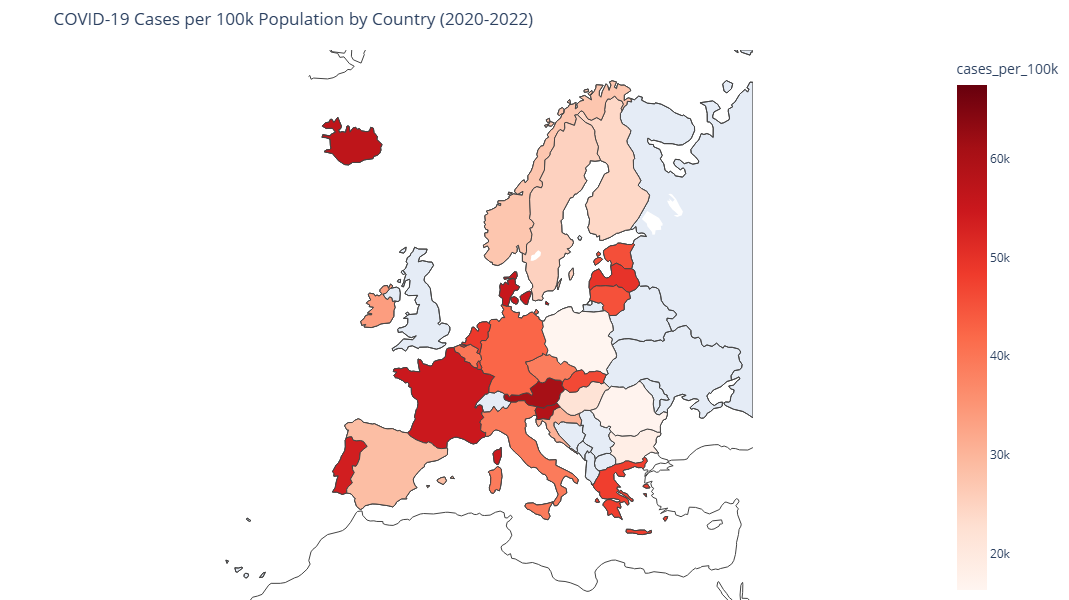

In [78]:
import plotly.express as px

# Aggregate total cases and population by country
map_cases = (
    q1_df.groupby(['countriesAndTerritories', 'countryterritoryCode'])
    .agg(
        total_cases=('cases', 'sum'),
        population=('popData2020', 'first')
    )
    .reset_index()
)

# Calculate cases per 100k population
map_cases['cases_per_100k'] = (
    map_cases['total_cases'] /
    map_cases['population']
) * 100000

# Choropleth map
fig = px.choropleth(
    map_cases,
    locations='countryterritoryCode',
    color='cases_per_100k',
    hover_name='countriesAndTerritories',
    hover_data={
        'total_cases': ':,.0f',
        'population': ':,.0f',
        'cases_per_100k': ':,.0f',
        'countryterritoryCode': False
    },
    color_continuous_scale='Reds',
    title='COVID-19 Cases per 100k Population by Country (2020-2022)'
)

fig.update_geos(
    scope='europe',
    showcoastlines=True,
    showland=True,
    fitbounds='locations'
)

fig.update_layout(
    height=600,
    margin=dict(l=0, r=0, t=50, b=0)
)

fig.show()

**Observation**:
- The geographical visualization shows that many countries with high COVID-19 case numbers were located in Western and Central Europe. These countries are geographically close and highly connected through trade, tourism, and cross-border mobility within the European Union and the Schengen Area. This regional proximity and mobility may have contributed to similar transmission patterns across neighboring countries.
- When cases were adjusted for population size, some smaller countries also showed high infection rates. This indicates that raw case counts alone do not fully represent the relative pandemic impact across countries.
- This suggests that COVID-19 outbreaks were not only country-specific but also followed broader regional and temporal patterns.

Overall, the analysis suggests both geographical and temporal synchronization among highly affected European countries. Regional proximity, mobility, and shared transmission dynamics likely contributed to the spread of COVID-19 across Europe, although differences in testing, reporting, public health measures, and population structure should also be considered.

## Q2: Map visualization of cases and deaths (2020–2022).

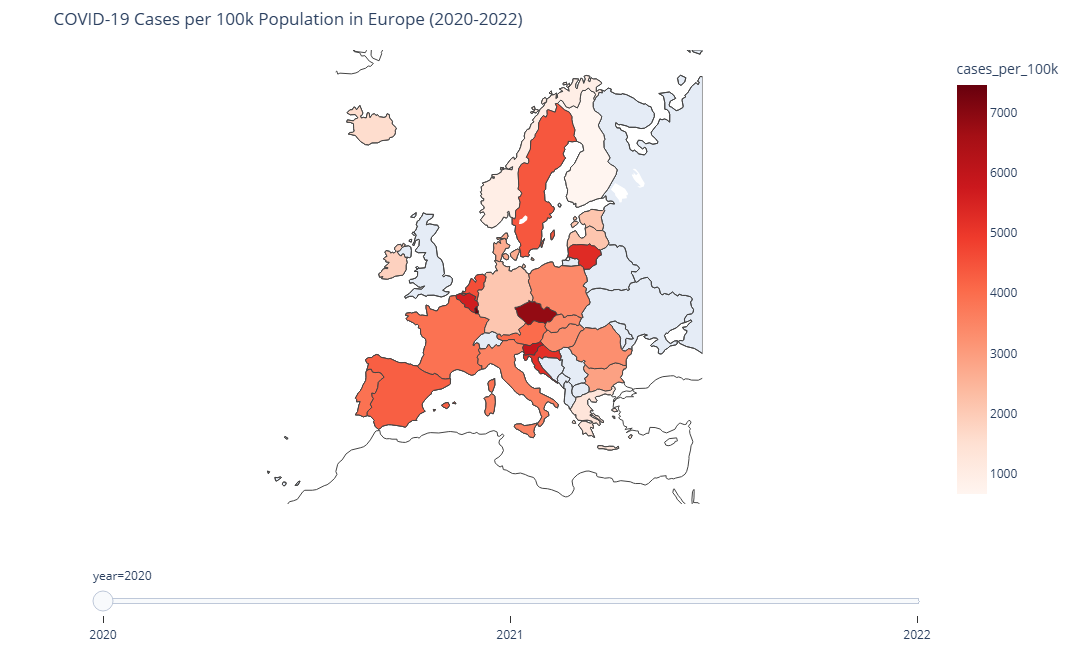

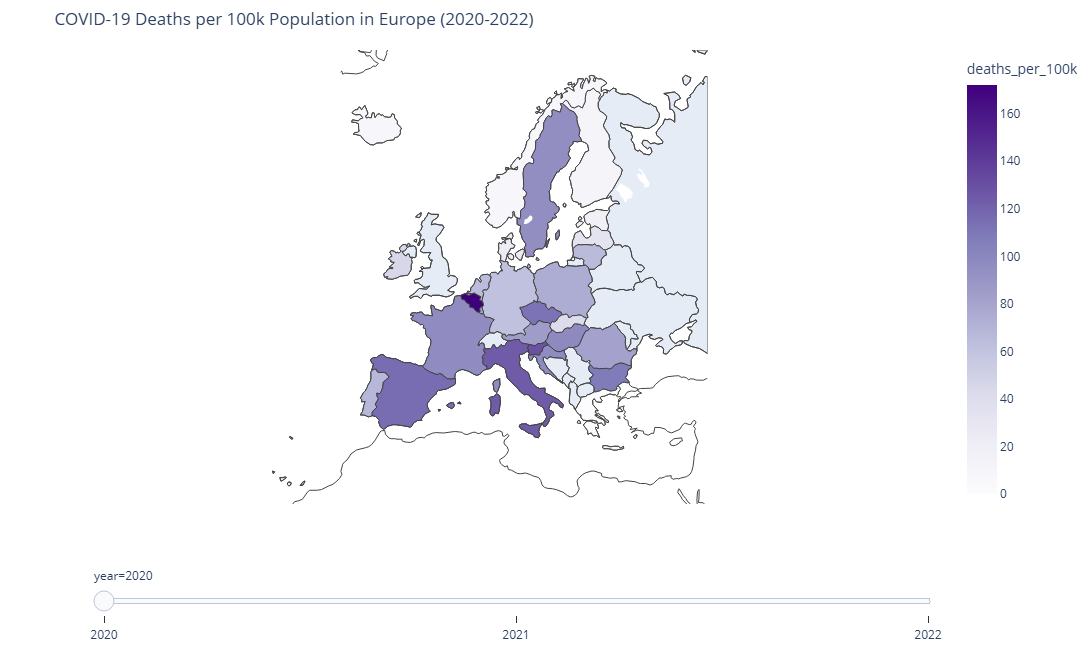

In [79]:
import plotly.express as px

# 1. Aggregate yearly cases and deaths by country
map_data = (
    cases_df.groupby(
        ['year', 'countriesAndTerritories', 'countryterritoryCode'],
        as_index=False
    )
    .agg(
        total_cases=('cases', 'sum'),
        total_deaths=('deaths', 'sum'),
        population=('popData2020', 'first')
    )
)

# Create per 100k metrics
map_data['cases_per_100k'] = (
    map_data['total_cases'] /
    map_data['population']
) * 100000

map_data['deaths_per_100k'] = (
    map_data['total_deaths'] /
    map_data['population']
) * 100000

# 2. MAP OF TOTAL CASES
fig_cases = px.choropleth(
    map_data,
    locations='countryterritoryCode',
    color='cases_per_100k',
    hover_name='countriesAndTerritories',
    animation_frame='year',
    color_continuous_scale='Reds',
    hover_data={
        'total_cases': ':,.0f',
        'population': ':,.0f',
        'cases_per_100k': ':.0f',
        'countryterritoryCode': False
    },
    title='COVID-19 Cases per 100k Population in Europe (2020-2022)'
)

fig_cases.update_geos(
    scope='europe',
    showcoastlines=True,
    showland=True,
    fitbounds='locations'
)

fig_cases.update_layout(
    updatemenus=[
        dict(
            type="buttons",
            buttons=[],
            showactive=False,
            x=0,
            y=0,
            visible=False
        )
    ],
    height=650,
    margin=dict(l=0, r=0, t=50, b=0)
)

fig_cases.show()

# 3. MAP OF TOTAL DEATHS
fig_deaths = px.choropleth(
    map_data,
    locations='countryterritoryCode',
    color='deaths_per_100k',
    hover_name='countriesAndTerritories',
    animation_frame='year',
    color_continuous_scale='Purples',
    hover_data={
        'total_deaths': ':,.0f',
        'population': ':,.0f',
        'deaths_per_100k': ':.0f',
        'countryterritoryCode': False
    },
    title='COVID-19 Deaths per 100k Population in Europe (2020-2022)'
)

fig_deaths.update_geos(
    scope='europe',
    showcoastlines=True,
    showland=True,
    fitbounds='locations'
)

fig_deaths.update_layout(
   updatemenus=[
        dict(
            type="buttons",
            buttons=[],
            showactive=False,
            x=0,
            y=0,
            visible=False
        )
    ],
    height=650,
    margin=dict(l=0, r=0, t=50, b=0)
)

fig_deaths.show()

**Observation:**
- The choropleth maps show COVID-19 cases and deaths per 100,000 population across European countries from 2020 to 2022.
- Darker colors indicate higher relative impact, while lighter colors indicate lower relative impact.
- Because the values are adjusted by population size, the maps show relative pandemic burden rather than only raw case or death totals. This means smaller countries can appear darker if they experienced high case or death rates compared with their population.
- COVID-19 cases and deaths were mainly concentrated in Western and Central Europe during 2020-2022.
- Countries such as France, Germany, Italy, and Spain showed high case levels, which may be related to their large populations, high mobility, and strong international connectivity.
- The geographical spread became more widespread over time, especially in 2021 and 2022. Many countries showed higher case intensity in 2022, likely related to the Omicron wave.
- The deaths map shows that several countries experienced high mortality rates in 2020 and 2021. However, in 2022, death intensity was generally lower compared with the high number of cases. This may reflect vaccination, improved treatment, and increased population immunity.
- Neighboring countries often showed similar patterns, suggesting regional transmission dynamics and synchronized pandemic waves.

Overall, the maps show that the COVID-19 impact varied geographically and over time across Europe. The results suggest that population-adjusted burden, regional proximity, cross-border mobility, and shared pandemic waves all played important roles in the spread and impact of COVID-19.

# Vaccination Brand and Distribution Analysis (Vaccination Data)
## Q3: The top 3 popular vaccine brands used across the EU/EEA and at the country level.

Descriptions of Vaccine Brand Codes Used in the Dataset

| Code  | Vaccine Brand |
|-------|------------------------------|
| COM   | Comirnaty / Pfizer-BioNTech |
| MOD   | Moderna / Spikevax |
| AZ    | AstraZeneca / Vaxzevria |
| JANSS | Janssen |
| NVXD  | Novavax |
| UNK   | Unknown vaccine brand |

,Vaccine,total_first_dose
0,COM,455.883.035
1,UNK,289.412.190
2,AZ,72.640.842


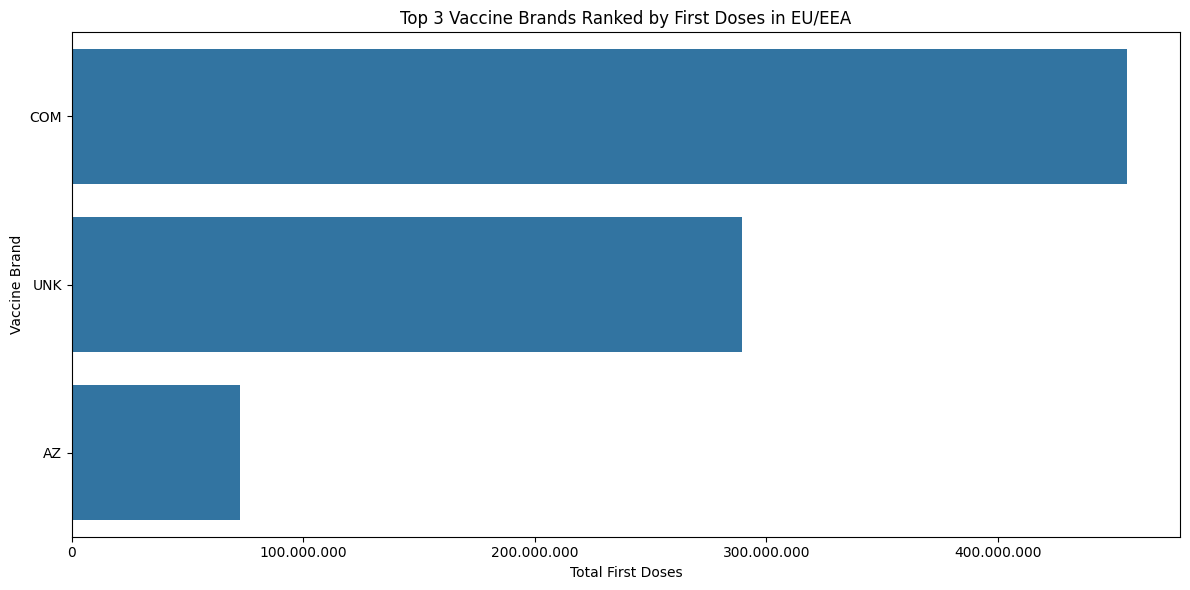

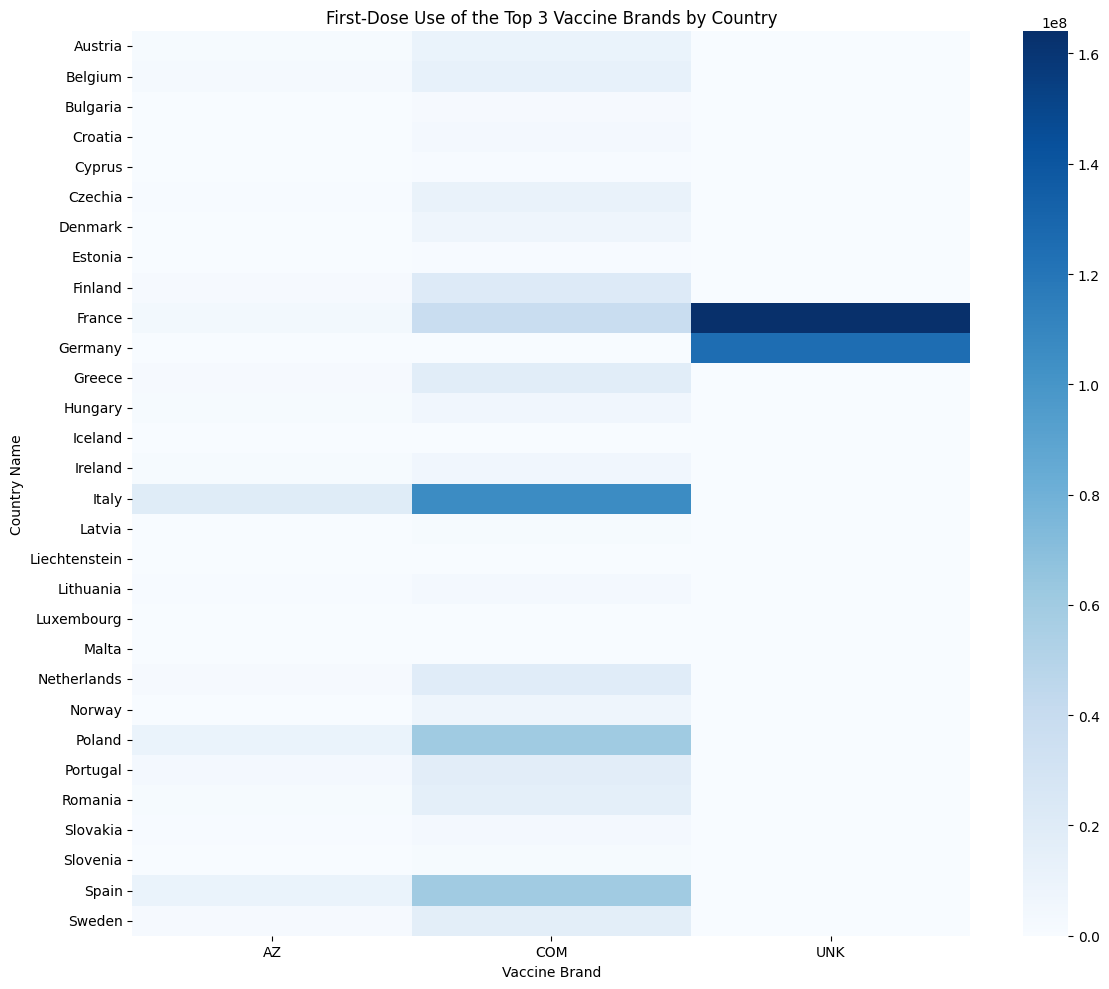

In [80]:
import matplotlib.ticker as mticker
# Top 3 most popular vaccine brands
vaccine_totals = (
    vacc_df.groupby('Vaccine')
    .agg(
        total_first_dose=('FirstDose', 'sum')
    )
    .reset_index()
)

# Sort and select top 3
top3_vaccines = (
    vaccine_totals
    .sort_values('total_first_dose', ascending=False)
    .head(3)
)

top3_vaccines_formatted = top3_vaccines.copy()

top3_vaccines_formatted[
    ['total_first_dose']
] = top3_vaccines_formatted[
    ['total_first_dose']
].map(
    lambda x: f"{x:,.0f}".replace(",", ".")
)

top3_vaccines_formatted = top3_vaccines_formatted.reset_index(drop=True)
display(top3_vaccines_formatted)

# Bar chart: Top 3 vaccine brands
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=top3_vaccines,
    x='total_first_dose',
    y='Vaccine'
)

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", "."))
)

plt.title("Top 3 Vaccine Brands Ranked by First Doses in EU/EEA")
plt.xlabel("Total First Doses")
plt.ylabel("Vaccine Brand")

plt.tight_layout()
plt.show()

# Add full country names to vaccination dataset
country_lookup = (
    cases_df[['geoId', 'countriesAndTerritories']]
    .drop_duplicates()
    .rename(columns={
        'geoId': 'ReportingCountry',
        'countriesAndTerritories': 'country_name'
    })
)

# Avoid duplicate country_name column if this cell is run again
vacc_df = vacc_df.drop(columns=['country_name'], errors='ignore')

vacc_df = vacc_df.merge(
    country_lookup,
    on='ReportingCountry',
    how='left'
)

# Vaccine popularity by country using full country names
country_vaccine = (
    vacc_df.groupby(['country_name', 'Vaccine'])
    .agg(
        total_first_dose=('FirstDose', 'sum')
    )
    .reset_index()
)

# Keep only top 3 vaccines
country_vaccine = country_vaccine[
    country_vaccine['Vaccine'].isin(top3_vaccines['Vaccine'])
]

# Heatmap
heatmap_vaccine = country_vaccine.pivot_table(
    values='total_first_dose',
    index='country_name',
    columns='Vaccine',
    aggfunc='sum',
    fill_value=0
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    heatmap_vaccine,
    cmap='Blues'
)

plt.title("First-Dose Use of the Top 3 Vaccine Brands by Country")
plt.xlabel("Vaccine Brand")
plt.ylabel("Country Name")

plt.tight_layout()
plt.show()

**Observation:**
- The bar chart shows that a small number of vaccine brands accounted for most first-dose vaccinations across the EU/EEA.
- The heatmap indicates that vaccine usage varied across countries.
- Some vaccine brands were widely used across many countries, while others were concentrated in specific countries.
- Countries with larger populations generally administered higher numbers of first doses.

Overall, the results suggest that vaccine adoption was not uniform across the EU/EEA and was likely influenced by national vaccination strategies and vaccine availability.

## Q4: Target groups received the popular vaccine brands in each country

| Simplified Category | Original Target Groups |
|--------------------|------------------------|
| HCW | Healthcare workers |
| LTCF | Long-term care facility residents |
| ALL | General population |
| Age < 18 | Age<18, Age0_4, Age5_9, Age10_14, Age15_17 |
| Age 18-49 | Age18_24, Age25_49 |
| Age 50+ | Age50_59, 1_Age<60, 1_Age60+, Age60_69, Age70_79, Age80+ |

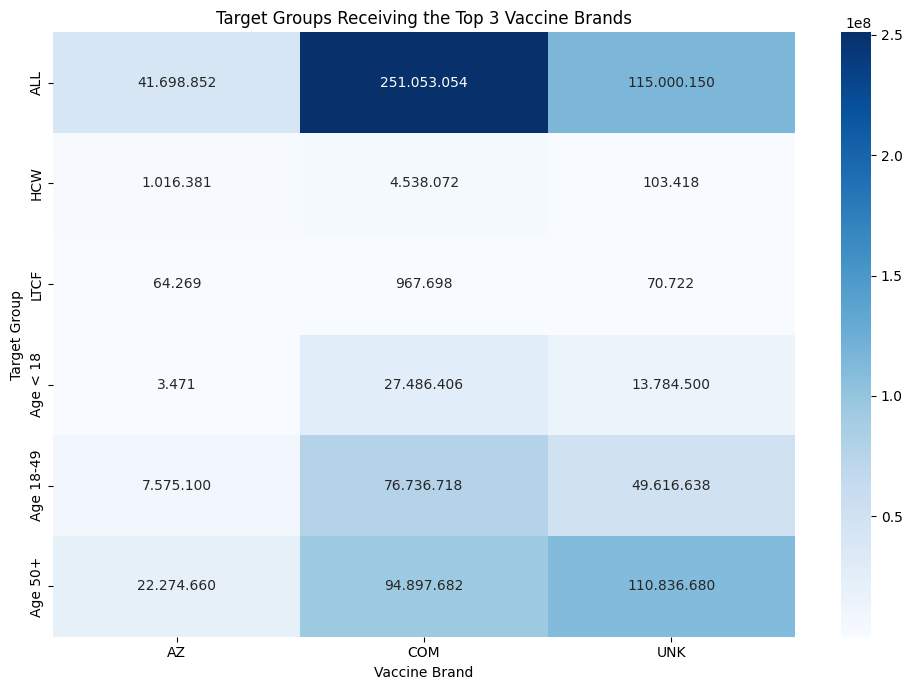

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create simplified target group categories in vacc_df
def simplify_target_group(group):
    if group == 'HCW':
        return 'HCW'
    elif group == 'LTCF':
        return 'LTCF'
    elif group == 'ALL':
        return 'ALL'
    elif group == 'AgeUNK':
        return 'UNK'
    elif group in ['Age<18', 'Age0_4', 'Age5_9', 'Age10_14', 'Age15_17']:
        return 'Age < 18'
    elif group in ['Age18_24', 'Age25_49']:
        return 'Age 18-49'
    elif group in ['Age50_59', '1_Age<60', '1_Age60+', 'Age60_69', 'Age70_79', 'Age80+']:
        return 'Age 50+'
    else:
        return 'Other'

vacc_df['TargetGroup_Category'] = vacc_df['TargetGroup'].apply(simplify_target_group)

# 2. Create target group dataframe from vacc_df
vacc_target_group_df = (
    vacc_df
    .groupby(['ReportingCountry', 'TargetGroup', 'TargetGroup_Category', 'Vaccine'], as_index=False)
    .agg(
        total_first_dose=('FirstDose', 'sum'),
        population=('Population', 'first')
    )
)

# 3. Get top 3 vaccine brands based on total first doses
vaccine_usage = (
    vacc_df
    .groupby('Vaccine', as_index=False)
    .agg(total_first_dose=('FirstDose', 'sum'))
)

top_3_vaccines = (
    vaccine_usage
    .sort_values('total_first_dose', ascending=False)
    .head(3)['Vaccine']
)

# 4. Filter to top 3 vaccines and exclude UNK
vacc_target_group_top3 = vacc_target_group_df[
    (vacc_target_group_df['Vaccine'].isin(top_3_vaccines)) &
    (vacc_target_group_df['TargetGroup_Category'] != 'UNK')
]

# 5. Summarize total first doses by simplified target group and vaccine
target_group_top3_summary = (
    vacc_target_group_top3
    .groupby(['TargetGroup_Category', 'Vaccine'], as_index=False)
    .agg(total_first_dose=('total_first_dose', 'sum'))
)

# 6. Create pivot table for heatmap
heatmap_target_group_top3 = target_group_top3_summary.pivot_table(
    values='total_first_dose',
    index='TargetGroup_Category',
    columns='Vaccine',
    aggfunc='sum',
    fill_value=0
)

# 7. Reorder target groups
target_order = ['ALL', 'HCW', 'LTCF', 'Age < 18', 'Age 18-49', 'Age 50+']

heatmap_target_group_top3 = (
    heatmap_target_group_top3
    .reindex(target_order)
    .dropna(how='all')
)

# 8. Format annotation with dot as thousands separator
heatmap_labels = heatmap_target_group_top3.map(
    lambda x: f"{int(x):,}".replace(",", ".")
)

# 9. Plot heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    heatmap_target_group_top3,
    cmap='Blues',
    annot=heatmap_labels,
    fmt=''
)

plt.title("Target Groups Receiving the Top 3 Vaccine Brands")
plt.xlabel("Vaccine Brand")
plt.ylabel("Target Group")

plt.tight_layout()
plt.show()

**Observation**:
- The heatmap shows how the top 3 vaccine brands were distributed across different target groups.
- Darker cells represent higher numbers of first doses.
- The ALL category usually dominates because it represents the general population.
- Age-based groups show differences in vaccine use, suggesting that vaccination strategies vary by age group.
- Healthcare workers (HCW) and long-term care facility residents (LTCF) may show smaller totals because they are smaller target populations.

Overall, the visualization suggests that vaccine distribution was not uniform across target groups and was influenced by population size, eligibility, and national vaccination priorities.

# Vaccine Skepticism and Hospitalization
## Q5: The most skeptical countries towards the first dose of the COVID-19 vaccine.

,Country,Total First Doses,Population,First-Dose Coverage (%)
0,BG,2.077.742,6.951.482,"29,89"
1,RO,7.917.501,19.201.662,"41,23"
2,SK,2.704.559,5.459.781,"49,54"
3,SI,1.180.783,2.108.977,"55,99"
4,HR,2.282.163,4.058.165,"56,24"
5,EE,796.997,1.331.796,"59,84"
6,HU,5.921.482,9.769.526,"60,61"
7,CZ,6.551.506,10.701.777,"61,22"
8,LI,25.061,39.308,"63,76"
9,LU,425.605,645.397,"65,94"


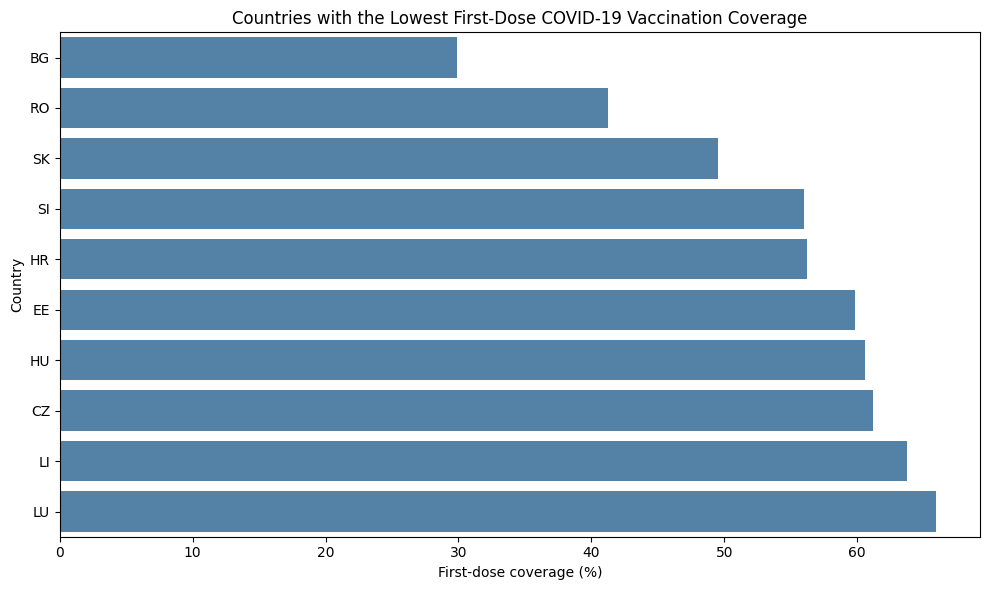

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use vaccination dataset
vacc_df = pd.read_csv("2.COVID-19_vaccination.csv")

# Use only ALL target group to avoid double counting age groups
vacc_all = vacc_df[vacc_df["TargetGroup"] == "ALL"].copy()

# Summarize first doses and population by country
skepticism_df = (
    vacc_all
    .groupby("ReportingCountry", as_index=False)
    .agg(
        total_first_dose=("FirstDose", "sum"),
        population=("Population", "max")
    )
)

# Calculate first-dose coverage percentage
skepticism_df["first_dose_coverage_percent"] = (
    skepticism_df["total_first_dose"] / skepticism_df["population"]
) * 100

# Sort from lowest to highest coverage
lowest_coverage_countries = (
    skepticism_df
    .sort_values("first_dose_coverage_percent", ascending=True)
    .head(10)
)

lowest_coverage_display = lowest_coverage_countries.rename(columns={
    "ReportingCountry": "Country",
    "total_first_dose": "Total First Doses",
    "population": "Population",
    "first_dose_coverage_percent": "First-Dose Coverage (%)"
})

# Format numbers and percentages
lowest_coverage_display["Total First Doses"] = lowest_coverage_display["Total First Doses"].map(
    lambda x: f"{int(x):,}".replace(",", ".")
)

lowest_coverage_display["Population"] = lowest_coverage_display["Population"].map(
    lambda x: f"{int(x):,}".replace(",", ".")
)

lowest_coverage_display["First-Dose Coverage (%)"] = lowest_coverage_display["First-Dose Coverage (%)"].map(
    lambda x: f"{x:.2f}".replace(".", ",")
)

lowest_coverage_display = lowest_coverage_display.reset_index(drop=True)

display(lowest_coverage_display)

# Plot
plt.figure(figsize=(10, 6))

sns.barplot(
    data=lowest_coverage_countries,
    x="first_dose_coverage_percent",
    y="ReportingCountry",
    color="steelblue"
)

plt.title("Countries with the Lowest First-Dose COVID-19 Vaccination Coverage")
plt.xlabel("First-dose coverage (%)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

**Observation:**
- Bulgaria (BG) had the lowest first-dose vaccination coverage among the analyzed EU/EEA countries, with only 29.89% of the population receiving a first vaccine dose.
- Romania (RO) and Slovakia (SK) also reported relatively low first-dose coverage rates of 41.23% and 49.54%, respectively.
- Considerable variation can be observed across the ten lowest-ranked countries, ranging from below 30% in Bulgaria to approximately 66% in Luxembourg.
- Several Eastern and Central European countries appear among the countries with the lowest first-dose coverage, suggesting regional differences in vaccine uptake.
- Lower first-dose vaccination coverage may indicate higher levels of vaccine hesitancy, lower public confidence in vaccination, differences in vaccine access, or variation in national vaccination policies.

Overall, the results show substantial differences in first-dose vaccination uptake across EU/EEA countries. Bulgaria, Romania, and Slovakia had the lowest vaccination coverage and may represent countries with higher potential vaccine hesitancy. However, vaccination coverage alone cannot directly measure public attitudes toward vaccination, since uptake may also be influenced by vaccine availability, healthcare access, reporting practices, and government policies.

# Vaccination Coverage and Demographic Analysis
## Q6: Countries with the most and the least vaccinated people under 18 regarding their total populations.

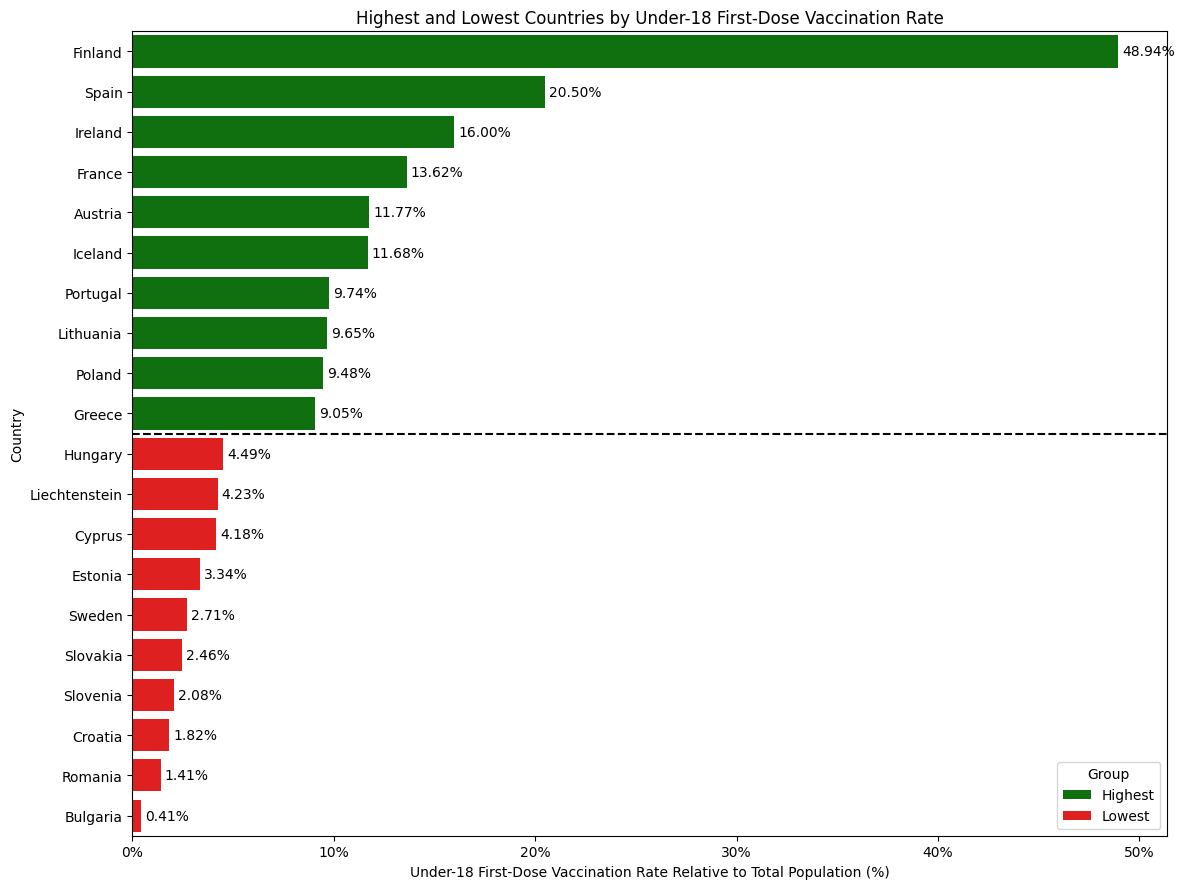

In [83]:
# Add full country names to vaccination dataset
country_lookup = (
    cases_df[['geoId', 'countriesAndTerritories']]
    .drop_duplicates()
    .rename(columns={
        'geoId': 'ReportingCountry',
        'countriesAndTerritories': 'country_name'
    })
)

vacc_df = vacc_df.drop(columns=['country_name'], errors='ignore')

vacc_df = vacc_df.merge(
    country_lookup,
    on='ReportingCountry',
    how='left'
)

# Create TargetGroup_Category
def simplify_target_group(group):
    if group in ['Age<18', 'Age0_4', 'Age5_9', 'Age10_14', 'Age15_17']:
        return 'Age < 18'
    elif group in ['Age18_24', 'Age25_49']:
        return 'Age 18-49'
    elif group in ['Age50_59', 'Age60_69', 'Age70_79', 'Age80+']:
        return 'Age 50+'
    elif group == 'HCW':
        return 'HCW'
    elif group == 'LTCF':
        return 'LTCF'
    elif group == 'ALL':
        return 'ALL'
    elif group == 'AgeUNK':
        return 'UNK'
    else:
        return 'Other'

vacc_df['TargetGroup_Category'] = vacc_df['TargetGroup'].apply(simplify_target_group)


# Filter under-18 target groups
under18_data = vacc_df[
    vacc_df['TargetGroup_Category'] == 'Age < 18'
].copy()

# Summarize first doses under 18 by country
under18_summary = (
    under18_data
    .groupby(['ReportingCountry', 'country_name'], as_index=False)
    .agg(
        under18_first_dose=('FirstDose', 'sum'),
        population=('Population', 'first')
    )
)

# Calculate under-18 first-dose rate relative to total population
under18_summary['under18_first_dose_rate'] = (
    under18_summary['under18_first_dose'] /
    under18_summary['population']
) * 100

# Remove missing or invalid values
under18_summary = under18_summary.dropna(
    subset=['country_name', 'under18_first_dose_rate']
)

# Sort countries by under-18 first-dose rate
under18_summary = under18_summary.sort_values(
    'under18_first_dose_rate',
    ascending=False
).reset_index(drop=True)

# Select top 10 and lowest 10 countries
top10_under18 = under18_summary.head(10).copy()
lowest10_under18 = under18_summary.tail(10).copy()

top10_under18['Group'] = 'Highest'
lowest10_under18['Group'] = 'Lowest'

combined_under18 = pd.concat(
    [top10_under18, lowest10_under18],
    ignore_index=True
)

combined_under18 = combined_under18.sort_values(
    by='under18_first_dose_rate',
    ascending=False
).reset_index(drop=True)

# Plot
plt.figure(figsize=(12, 9))

ax = sns.barplot(
    data=combined_under18,
    x='under18_first_dose_rate',
    y='country_name',
    hue='Group',
    palette={
        'Highest': 'green',
        'Lowest': 'red'
    },
    dodge=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f%%',
        padding=3
    )

plt.axhline(
    y=9.5,
    color='black',
    linestyle='--',
    linewidth=1.5
)

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f"{x:.0f}%")
)

plt.title("Highest and Lowest Countries by Under-18 First-Dose Vaccination Rate")
plt.xlabel("Under-18 First-Dose Vaccination Rate Relative to Total Population (%)")
plt.ylabel("Country")

plt.legend(title="Group")

plt.tight_layout()
plt.show()

**Observations:**

- The analysis shows substantial variation in under-18 first-dose vaccination rates across EU/EEA countries.
- First-dose vaccination counts were used to estimate vaccination uptake among individuals under 18 years old because combining first and second doses could result in double counting and overestimate coverage.
- Finland reported the highest under-18 first-dose vaccination rate relative to its total population (48.94%), substantially higher than the other countries in the top group.
- Spain, Ireland, France, Austria, and Iceland also exhibited relatively high under-18 vaccination rates, indicating broader vaccine uptake among children and adolescents.
- Bulgaria reported the lowest under-18 first-dose vaccination rate (0.41%), followed by Romania (1.41%) and Croatia (1.82%), suggesting considerably lower vaccination uptake among younger age groups.
- The large gap between the highest- and lowest-ranked countries highlights significant differences in vaccination uptake across the EU/EEA.
- These differences may be associated with factors such as national vaccination policies, vaccine eligibility criteria, vaccine availability, parental acceptance, and public confidence in vaccination.

Overall, the results indicate that under-18 vaccination uptake was not uniform across EU/EEA countries. While some countries achieved relatively high first-dose coverage among children and adolescents, others reported substantially lower uptake, reflecting differences in vaccination strategies and implementation across Europe.

## Q7: The countries with the oldest vaccinated population for the second dose vaccine in relation to their total population.

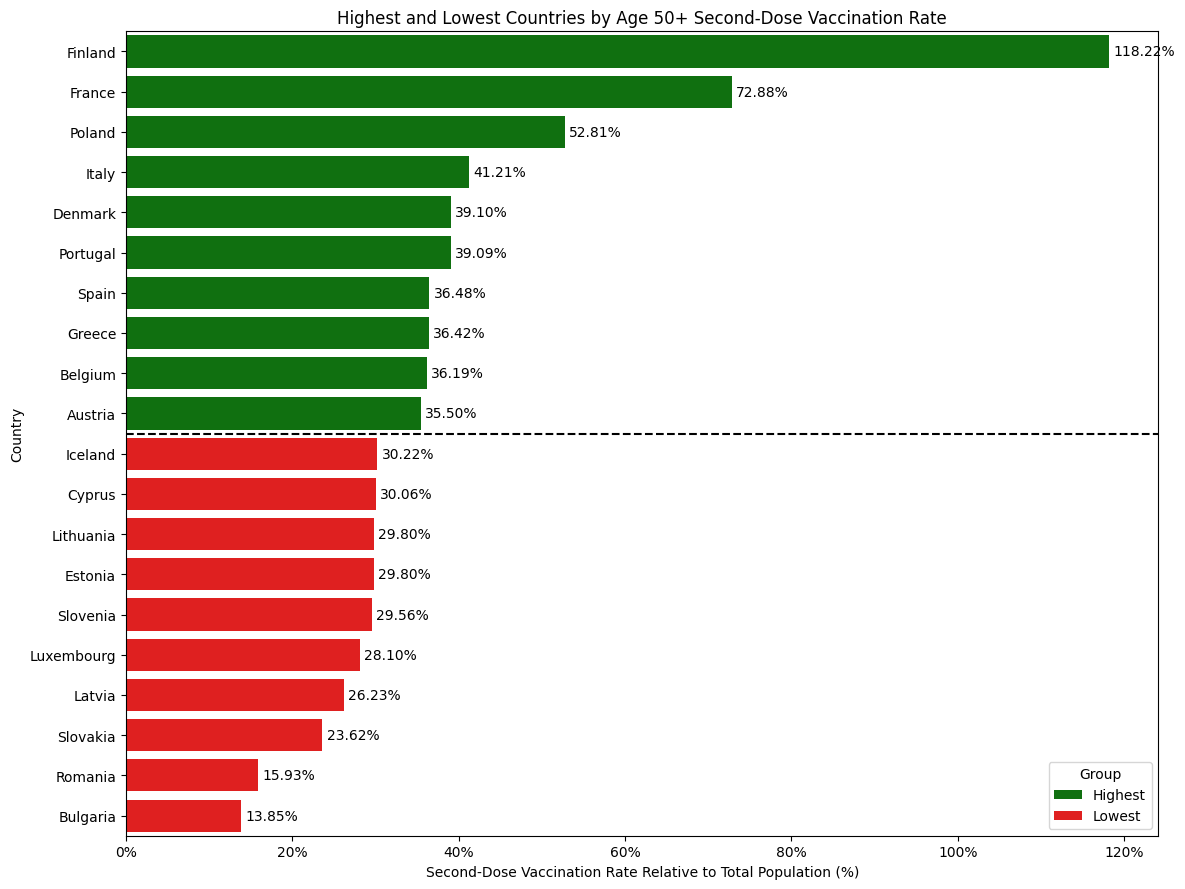

In [84]:
# 1. Filter elderly target groups
oldest_df = vacc_df[
    vacc_df['TargetGroup_Category'] == 'Age 50+'
].copy()

# 2. Aggregate second-dose vaccination by country
oldest_summary = (
    oldest_df.groupby('country_name', as_index=False)
    .agg(
        total_second_dose=('SecondDose', 'sum'),
        population=('Population', 'first')
    )
)

# Remove invalid values
oldest_summary = oldest_summary[
    (oldest_summary['total_second_dose'] > 0) &
    (oldest_summary['population'] > 0)
].copy()


# 3. Calculate oldest second-dose vaccination rate
oldest_summary['oldest_second_dose_rate'] = (
    oldest_summary['total_second_dose'] /
    oldest_summary['population']
) * 100


# 4. Rank countries
oldest_summary = oldest_summary.sort_values(
    by='oldest_second_dose_rate',
    ascending=False
).reset_index(drop=True)

# 5. Visualization: Top 10 and Lowest 10 countries
top10_oldest = oldest_summary.head(10).copy()
lowest10_oldest = oldest_summary.tail(10).copy()

# Add group labels
top10_oldest['Group'] = 'Highest'
lowest10_oldest['Group'] = 'Lowest'

# Combine groups
combined_oldest = pd.concat(
    [top10_oldest, lowest10_oldest],
    ignore_index=True
)

# Sort from highest to lowest
combined_oldest = combined_oldest.sort_values(
    by='oldest_second_dose_rate',
    ascending=False
).reset_index(drop=True)

# Plot
plt.figure(figsize=(12, 9))

ax = sns.barplot(
    data=combined_oldest,
    x='oldest_second_dose_rate',
    y='country_name',
    hue='Group',
    palette={
        'Highest': 'green',
        'Lowest': 'red'
    },
    dodge=False
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f%%',
        padding=3
    )

# Separator line
plt.axhline(
    y=9.5,
    color='black',
    linestyle='--',
    linewidth=1.5
)

# Format x-axis
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f"{x:.0f}%")
)

plt.title(
    "Highest and Lowest Countries by Age 50+ Second-Dose Vaccination Rate"
)

plt.xlabel("Second-Dose Vaccination Rate Relative to Total Population (%)")
plt.ylabel("Country")
plt.legend(title="Group")

plt.tight_layout()
plt.show()

**Observation**:
- The analysis shows substantial differences in second-dose vaccination uptake among the Age 50+ population across EU/EEA countries.
- Finland and Greece reported the highest Age 50+ second-dose vaccination rates relative to their total populations, followed by France and Germany.
- Bulgaria reported the lowest Age 50+ second-dose vaccination rate, followed by Slovakia and Latvia.
- The large gap between the highest- and lowest-ranked countries indicates considerable variation in vaccination rollout and uptake among older populations.
- Countries in the highest-ranked group generally showed much higher second-dose uptake among older adults, suggesting stronger vaccination coverage among groups at greater risk of severe COVID-19 outcomes.
- The visualization highlights the contrast between countries with extensive vaccination uptake among older populations and those with comparatively lower uptake.

**Important Limitation**:
Some countries reported rates above 100% because the simplified Age 50+ category combines multiple detailed and aggregated target groups that may overlap. Therefore, these values should be interpreted as a descriptive comparison of vaccination patterns, not as exact vaccination coverage percentages for unique individuals aged 50 and above.

Overall, the results indicate that EU/EEA countries differed substantially in second-dose vaccination uptake among older populations. These differences may reflect variation in vaccination strategies, reporting practices, and population prioritization during the COVID-19 vaccination campaign.

# Healthcare System Impact (Hospital and ICU Data)
## Q8: The most affected countries’ health care by the coronavirus pandemic in 2020.

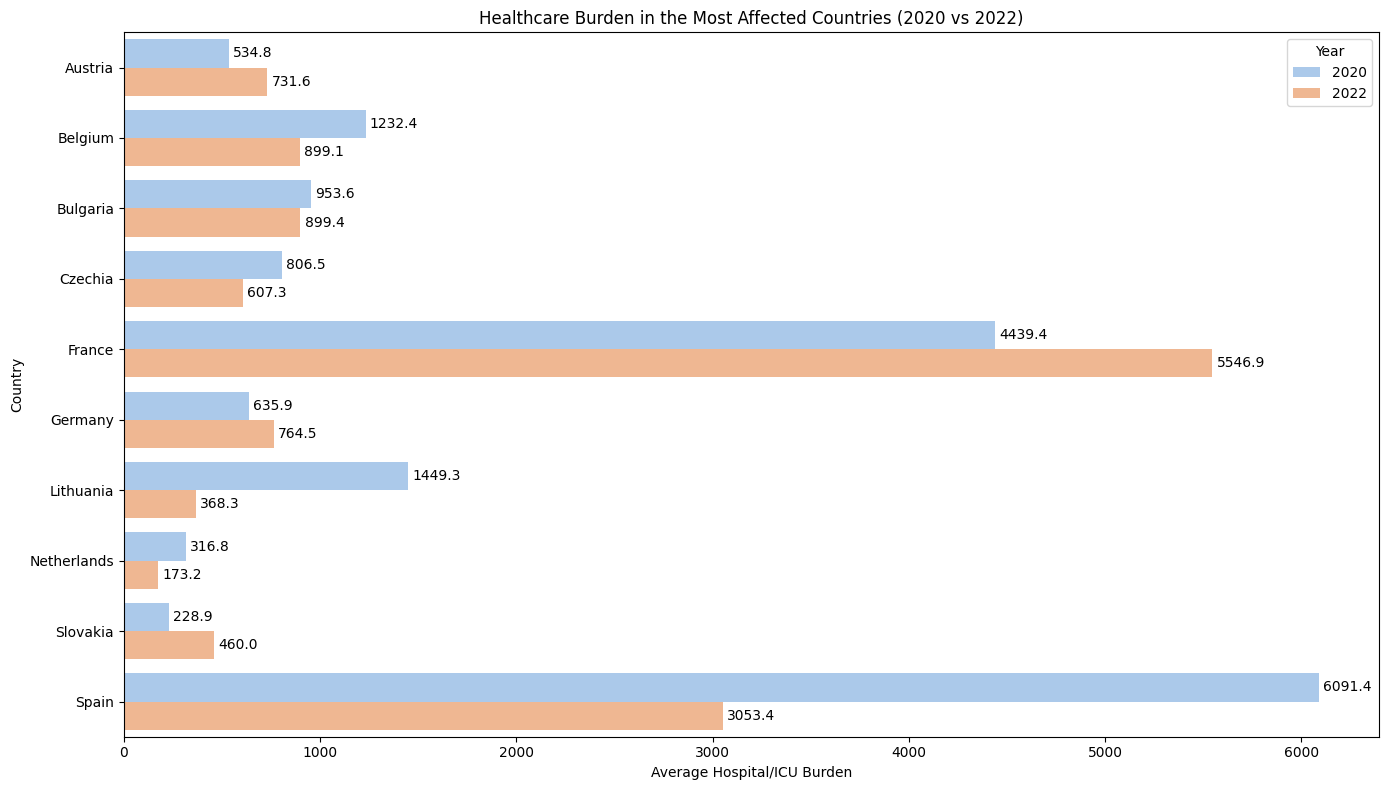

In [85]:
# 1. Filter years 2020 and 2022
healthcare_df = hospital_df[
    hospital_df['year'].isin([2020, 2022])
].copy()

# 2. Aggregate healthcare burden by country and year
healthcare_summary = (
    healthcare_df
    .groupby(['country', 'year'], as_index=False)
    .agg(
        average_healthcare_burden=('value', 'mean')
    )
)

# 3. Find the most affected countries in 2020
top_countries_2020 = (
    healthcare_summary[
        healthcare_summary['year'] == 2020
    ]
    .sort_values('average_healthcare_burden', ascending=False)
    .head(10)['country']
)

# 4. Keep only those countries for both years
comparison_data = healthcare_summary[
    healthcare_summary['country'].isin(top_countries_2020)
].copy()

# 5. Plot comparison
plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=comparison_data,
    x='average_healthcare_burden',
    y='country',
    hue='year',
    palette='pastel'
)

# Add value labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f',
        padding=3
    )

plt.title(
    "Healthcare Burden in the Most Affected Countries (2020 vs 2022)"
)

plt.xlabel("Average Hospital/ICU Burden")
plt.ylabel("Country")
plt.legend(title="Year")

plt.tight_layout()
plt.show()

**Observation:**

- The chart compares healthcare burden in 2020 and 2022 for the 10 countries with the highest average healthcare burden in 2020.
- Healthcare burden was measured using the average hospital and ICU occupancy values reported in the dataset.
- Higher values indicate greater pressure on healthcare systems during the COVID-19 pandemic.
Spain and France showed the highest healthcare burden among the selected countries, indicating sustained pressure on healthcare services.
- Several countries, including Spain, Belgium, Lithuania, the Netherlands, Czechia, and Bulgaria, experienced lower healthcare burden in 2022 than in 2020.
- In contrast, France, Germany, Austria, and Slovakia showed higher healthcare burden values in 2022, suggesting that healthcare pressure remained substantial in some countries after the initial pandemic period.
- Romania had no available hospital or ICU records for 2020 and was therefore not included in the comparison.
- The differences between 2020 and 2022 may be associated with vaccination coverage, improved clinical treatment, healthcare preparedness, virus variants, and public health interventions.

Overall, the results indicate that the healthcare burden decreased or stabilized in several EU/EEA countries by 2022. However, some countries continued to experience considerable pressure on their healthcare systems, showing that the effects of COVID-19 persisted beyond the initial pandemic year.

# Interesting Question to Investigate 
| No. | Research Question                                                                                                          | Datasets Used                                     | Method                                                                                                             | Suggested Plot                    | Observation Focus                                                                                          |
| --- | -------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------ | --------------------------------- | ---------------------------------------------------------------------------------------------------------- |
| 1   | Did countries with higher first-dose vaccination rates experience lower COVID-19 death rates in 2022?                              | Vaccination dataset + cases and deaths dataset      | Merge country-level first-dose vaccination rates with death rates per 100,000 people. Use correlation analysis.    | Scatter plot with regression line | Check whether the trend line slopes downward and whether the correlation suggests a negative relationship. |
| 2   | Did countries with higher booster or additional-dose uptake show lower hospital or ICU pressure in later pandemic periods? | Vaccination dataset + hospital and ICU dataset      | Aggregate booster uptake by country and compare it with hospital/ICU indicators in 2022. Use correlation analysis. | Scatter plot with regression line | Check whether higher booster rates are associated with lower healthcare pressure.                          |
| 3   | Did countries with high COVID-19 case rates also experience high healthcare burden?                                        | Cases and deaths dataset + hospital and ICU dataset | Aggregate country-level case rates and compare them with hospital/ICU indicators. Use correlation analysis.        | Scatter plot or heatmap           | Check whether higher case rates are associated with higher hospital or ICU pressure.                       |

## Q1: Did countries with higher first-dose vaccination rates experience lower COVID-19 death rates in 2022?

**Method**:
1. Filtered vaccination data to records from 2020-2022.
2. Calculated cumulative first-dose vaccination uptake for each country using all first doses administered during 2020-2022.
3. Calculated the first-dose vaccination rate (%) by dividing cumulative first doses by population.
4. Calculated the COVID-19 death rate in 2022 as deaths per 100,000 population.
5. Merged vaccination and death data by country.
6. Used a scatter plot, regression line, and Pearson correlation coefficient to examine the relationship.

Correlation between first-dose vaccination rate and death rate: -0.417


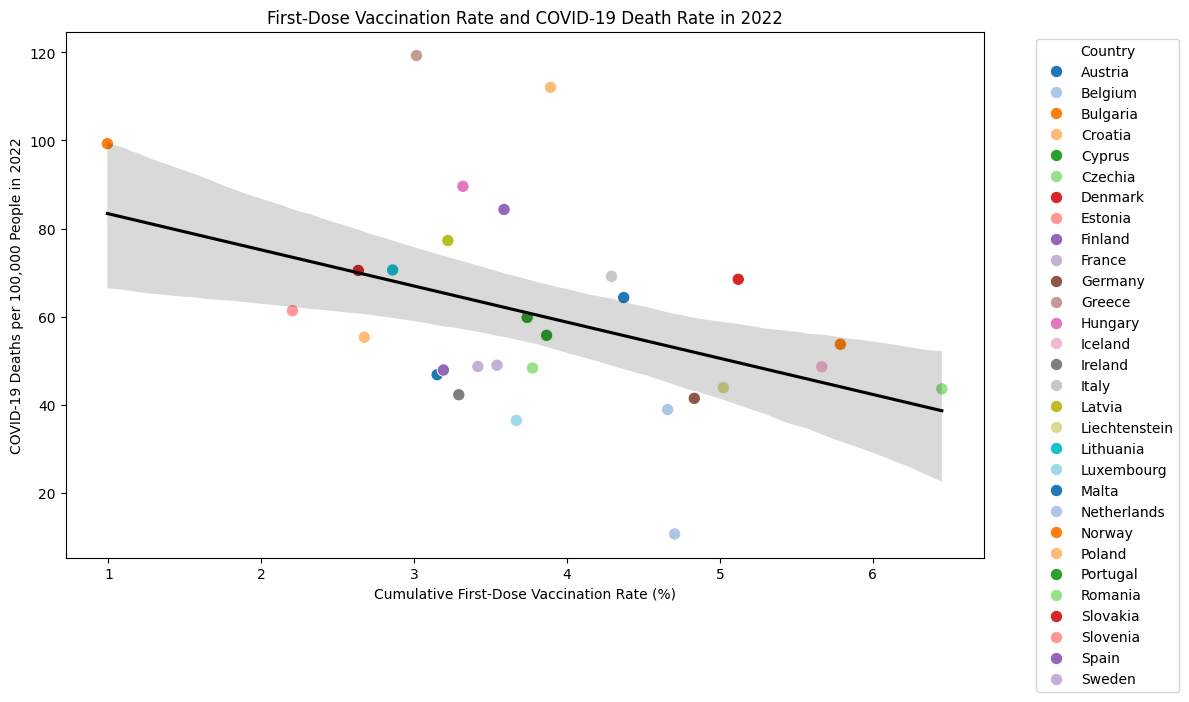

,country_name,total_first_dose,population,first_dose_rate,deaths_per_100k
25,Romania,1238654,19201662,6.45,43.60
22,Norway,313978,5425270,5.79,53.71
13,Iceland,20893,368792,5.67,48.61
6,Denmark,298083,5822763,5.12,68.47
17,Liechtenstein,1974,39308,5.02,43.87
10,Germany,4021725,83237124,4.83,41.44
21,Netherlands,821963,17475415,4.70,10.65
1,Belgium,541109,11617623,4.66,38.91
20,Malta,22554,516100,4.37,64.33
15,Italy,2532493,59030133,4.29,69.13


In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add country names to vaccination data
country_lookup = (
    cases_df[['geoId', 'countriesAndTerritories']]
    .drop_duplicates()
    .rename(columns={
        'geoId': 'ReportingCountry',
        'countriesAndTerritories': 'country_name'
    })
)

vacc_df = vacc_df.drop(columns=['country_name'], errors='ignore')

vacc_df = vacc_df.merge(
    country_lookup,
    on='ReportingCountry',
    how='left'
)

# Prepare cumulative first-dose vaccination coverage by country
vacc_df['year'] = vacc_df['YearWeekISO'].str[:4].astype(int)

vacc_2022_or_before = vacc_df[vacc_df['year'] <= 2022]

vacc_country_summary = (
    vacc_2022_or_before
    .groupby('country_name', as_index=False)
    .agg(
        total_first_dose=('FirstDose', 'max'),
        population=('Population', 'first')
    )
)

vacc_country_summary['first_dose_rate'] = (
    vacc_country_summary['total_first_dose'] /
    vacc_country_summary['population']
) * 100


# Prepare COVID-19 death rate in 2022
death_2022_summary = (
    cases_df[cases_df['year'] == 2022]
    .groupby('countriesAndTerritories', as_index=False)
    .agg(
        total_deaths=('deaths', 'sum'),
        population=('popData2020', 'first')
    )
)

death_2022_summary['deaths_per_100k'] = (
    death_2022_summary['total_deaths'] /
    death_2022_summary['population']
) * 100000

death_2022_summary = death_2022_summary.rename(
    columns={'countriesAndTerritories': 'country_name'}
)


# Merge vaccination and death data
q1_data = vacc_country_summary.merge(
    death_2022_summary[['country_name', 'deaths_per_100k']],
    on='country_name',
    how='inner'
)

# Remove missing or invalid values
q1_data = q1_data.dropna(
    subset=['first_dose_rate', 'deaths_per_100k']
)


# Calculate correlation
correlation_q1 = q1_data['first_dose_rate'].corr(
    q1_data['deaths_per_100k']
)

print(f"Correlation between first-dose vaccination rate and death rate: {correlation_q1:.3f}")


# Scatter plot with regression line
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=q1_data,
    x='first_dose_rate',
    y='deaths_per_100k',
    hue='country_name',
    s=80,
    palette='tab20'
)

sns.regplot(
    data=q1_data,
    x='first_dose_rate',
    y='deaths_per_100k',
    scatter=False,
    ci=95,
    color='black'
)

plt.title("First-Dose Vaccination Rate and COVID-19 Death Rate in 2022")
plt.xlabel("Cumulative First-Dose Vaccination Rate (%)")
plt.ylabel("COVID-19 Deaths per 100,000 People in 2022")

plt.legend(
    title="Country",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

# Display data table
q1_table = q1_data.sort_values(
    'first_dose_rate',
    ascending=False
).copy()

q1_table['first_dose_rate'] = q1_table['first_dose_rate'].round(2)
q1_table['deaths_per_100k'] = q1_table['deaths_per_100k'].round(2)

display(q1_table)

**Observation**:
- The scatter plot shows a downward trend between first-dose vaccination rate and COVID-19 death rate in 2022.
- Each point represents one EU/EEA country.
- Countries with higher first-dose vaccination rates generally tended to have lower COVID-19 death rates per 100,000 people.
- The Pearson correlation coefficient is r = -0.417, indicating a moderate negative relationship between the two variables.
- The regression line further supports this negative association.
- However, the data points remain dispersed around the trend line, suggesting considerable variation between countries.
- This indicates that vaccination coverage alone does not fully explain differences in COVID-19 mortality.
- Other factors, such as healthcare capacity, age structure, public health measures, virus variants, and prior immunity, may also have influenced death rates.

Overall, the analysis suggests that countries with higher first-dose vaccination rates tended to experience lower COVID-19 death rates in 2022. However, the relationship was moderate rather than strong and should be interpreted as an association rather than evidence of direct causation.

## Q2: Did countries with higher booster or additional-dose uptake show lower hospital or ICU pressure in later pandemic periods?

**Method**:
1. Filtered vaccination data to include records from 2020-2022.
2. Combined Dose: Additional 1 to Additional 5 to calculate total additional-dose vaccinations.
3. Aggregated total additional doses by country using the sum of doses administered during the study period.
4. Calculated the additional-dose vaccination rate (%) by dividing total additional doses by population size.
5. Calculated mean ICU pressure using average daily ICU occupancy in 2023.
6. Merged vaccination and ICU datasets by country.
7. Used a scatter plot, regression line, and Pearson correlation coefficient to examine the relationship between additional-dose uptake and ICU pressure.

Correlation between additional-dose rate and mean ICU pressure: 0.505


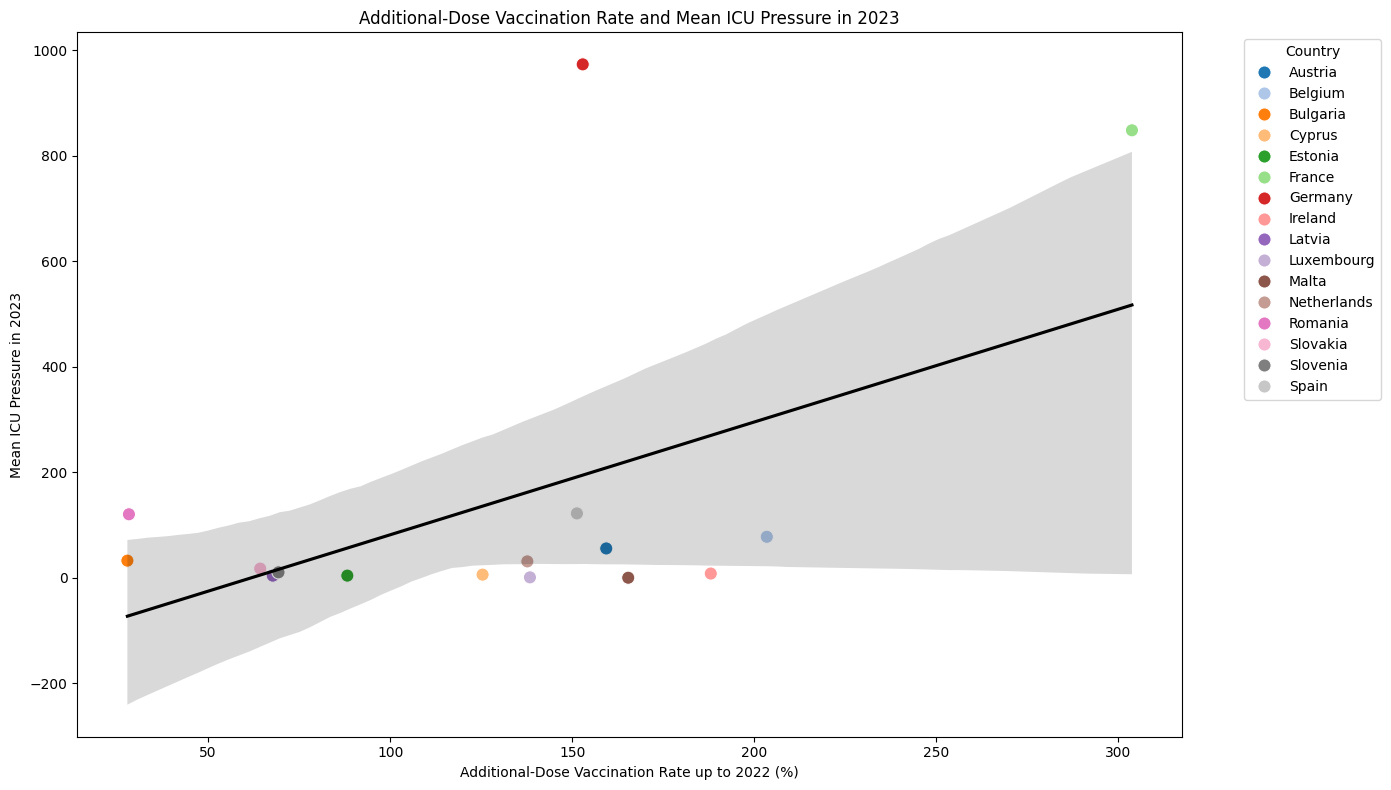

,country_name,total_booster,population,booster_rate,mean_icu_pressure,max_icu_pressure
5,France,205490002,67656682,303.72,848.59,1491.0
1,Belgium,23635129,11617623,203.44,77.97,132.0
7,Ireland,9414682,5006324,188.06,8.29,14.0
10,Malta,853548,516100,165.38,0.35,3.0
0,Austria,14234052,8932664,159.35,55.87,92.0
6,Germany,127259408,83237124,152.89,973.62,1375.0
15,Spain,71712185,47398695,151.30,122.29,214.0
9,Luxembourg,893209,645397,138.40,1.06,6.0
11,Netherlands,24058736,17475415,137.67,31.29,47.0
3,Cyprus,1134380,904705,125.39,6.23,10.0


In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create year column in vaccination dataset
vacc_df['year'] = vacc_df['YearWeekISO'].str[:4].astype(int)

# Use vaccination data before 2023
vacc_before_2023 = vacc_df[vacc_df['year'] <= 2022].copy()

# Additional-dose columns
additional_dose_cols = [
    'DoseAdditional1',
    'DoseAdditional2',
    'DoseAdditional3',
    'DoseAdditional4',
    'DoseAdditional5'
]

# Replace missing values with 0
vacc_before_2023[additional_dose_cols] = (
    vacc_before_2023[additional_dose_cols].fillna(0)
)

# Calculate total additional doses per row
vacc_before_2023['total_additional_doses'] = (
    vacc_before_2023[additional_dose_cols].sum(axis=1)
)

# Aggregate booster/additional doses by country
booster_country_summary = (
    vacc_before_2023
    .groupby('country_name', as_index=False)
    .agg(
        total_booster=('total_additional_doses', 'sum'),
        population=('Population', 'first')
    )
)

# Calculate booster/additional-dose rate
booster_country_summary['booster_rate'] = (
    booster_country_summary['total_booster'] /
    booster_country_summary['population']
) * 100


# Prepare ICU pressure data for 2023
selected_indicator = 'Daily ICU occupancy'

hospital_2023 = hospital_df[
    (hospital_df['year'] == 2023) &
    (hospital_df['indicator'] == selected_indicator)
].copy()

icu_2023_summary = (
    hospital_2023
    .groupby('country', as_index=False)
    .agg(
        mean_icu_pressure=('value', 'mean'),
        max_icu_pressure=('value', 'max')
    )
)

icu_2023_summary = icu_2023_summary.rename(
    columns={'country': 'country_name'}
)


# Merge vaccination and ICU data

q2_data = booster_country_summary.merge(
    icu_2023_summary,
    on='country_name',
    how='inner'
)

q2_data = q2_data.dropna(
    subset=['booster_rate', 'mean_icu_pressure']
)


# Correlation

correlation_q2 = q2_data['booster_rate'].corr(
    q2_data['mean_icu_pressure']
)

print(
    f"Correlation between additional-dose rate and mean ICU pressure: {correlation_q2:.3f}"
)


# Scatter plot
plt.figure(figsize=(14, 8))

sns.scatterplot(
    data=q2_data,
    x='booster_rate',
    y='mean_icu_pressure',
    hue='country_name',
    s=90,
    palette='tab20'
)

sns.regplot(
    data=q2_data,
    x='booster_rate',
    y='mean_icu_pressure',
    scatter=False,
    ci=95,
    color='black'
)

plt.title("Additional-Dose Vaccination Rate and Mean ICU Pressure in 2023")
plt.xlabel("Additional-Dose Vaccination Rate up to 2022 (%)")
plt.ylabel("Mean ICU Pressure in 2023")

plt.legend(
    title="Country",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

# Display result table
q2_table = q2_data.sort_values(
    'booster_rate',
    ascending=False
).copy()

q2_table['booster_rate'] = q2_table['booster_rate'].round(2)
q2_table['mean_icu_pressure'] = q2_table['mean_icu_pressure'].round(2)
q2_table['max_icu_pressure'] = q2_table['max_icu_pressure'].round(2)

q2_table = q2_table[
    [
        'country_name',
        'total_booster',
        'population',
        'booster_rate',
        'mean_icu_pressure',
        'max_icu_pressure'
    ]
]

display(q2_table)

**Observation**:
- The scatter plot shows a weak positive relationship between additional-dose vaccination rates and mean ICU pressure in 2023.
- Countries with higher additional-dose uptake did not consistently experience lower ICU pressure.
- The data points are widely dispersed, indicating substantial variation between countries.
-  The Pearson correlation coefficient is r = 0.505, indicating a moderate positive relationship between the two variables.
- The regression line shows only a slight upward trend, suggesting that additional-dose uptake was not strongly associated with ICU pressure levels.
- The wide confidence interval indicates uncertainty in the relationship.
- Several countries with high booster uptake still experienced relatively high ICU pressure, while some countries with lower booster uptake had lower ICU pressure.
- This suggests that ICU burden in 2023 was influenced by multiple factors beyond vaccination coverage alone.

Overall, the analysis did not find evidence that countries with higher additional-dose uptake consistently experienced lower ICU pressure in 2023. The relationship observed was weak, indicating that booster coverage alone was not a strong predictor of healthcare burden across EU/EEA countries.

## Q3: Did countries with high COVID-19 case rates also experience high healthcare burden?

**Method**:
1. Filtered COVID-19 case data for 2022.
2. Calculated total COVID-19 cases for each country.
3. Calculated the case rate per 100,000 population.
4. Filtered ICU occupancy data for 2022.
5. Calculated mean ICU pressure for each country.
6. Merged case and ICU datasets by country.
7. Used a scatter plot, regression line, and Pearson correlation coefficient to examine the relationship between case rates and healthcare burden.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare COVID-19 case rates for 2022
cases_2022_summary = (
    cases_df[cases_df['year'] == 2022]
    .groupby('countriesAndTerritories', as_index=False)
    .agg(
        total_cases=('cases', 'sum'),
        population=('popData2020', 'first')
    )
)

cases_2022_summary['cases_per_100k'] = (
    cases_2022_summary['total_cases'] /
    cases_2022_summary['population']
) * 100000

cases_2022_summary = cases_2022_summary.rename(
    columns={'countriesAndTerritories': 'country_name'}
)

# Select healthcare burden indicator
# Change if your dataset uses a different label
selected_indicator = 'Daily ICU occupancy'


# Filter healthcare data for 2022
hospital_2022 = hospital_df[
    (hospital_df['year'] == 2022) &
    (hospital_df['indicator'] == selected_indicator)
].copy()


# Aggregate healthcare burden by country
healthcare_2022_summary = (
    hospital_2022
    .groupby('country', as_index=False)
    .agg(
        mean_healthcare_pressure=('value', 'mean'),
        max_healthcare_pressure=('value', 'max')
    )
)

healthcare_2022_summary = healthcare_2022_summary.rename(
    columns={'country': 'country_name'}
)


# Merge case rates and healthcare burden
q3_data = cases_2022_summary.merge(
    healthcare_2022_summary,
    on='country_name',
    how='inner'
)

q3_data = q3_data.dropna(
    subset=['cases_per_100k', 'mean_healthcare_pressure']
)


# Calculate Pearson correlation
correlation_q3 = q3_data['cases_per_100k'].corr(
    q3_data['mean_healthcare_pressure']
)

print(f"Correlation between case rate and healthcare burden: {correlation_q3:.3f}")


# Scatter plot with regression line

plt.figure(figsize=(14, 8))

sns.scatterplot(
    data=q3_data,
    x='cases_per_100k',
    y='mean_healthcare_pressure',
    hue='country_name',
    s=90,
    palette='tab20'
)

sns.regplot(
    data=q3_data,
    x='cases_per_100k',
    y='mean_healthcare_pressure',
    scatter=False,
    ci=95,
    color='black'
)

plt.title("COVID-19 Case Rate and ICU Pressure in 2022")
plt.xlabel("COVID-19 Cases per 100,000 People")
plt.ylabel("Mean ICU Pressure in 2022")

plt.legend(
    title="Country",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

# 9. Display table
q3_table = q3_data.sort_values(
    'cases_per_100k',
    ascending=False
).copy()

q3_table['cases_per_100k'] = q3_table['cases_per_100k'].round(2)
q3_table['mean_healthcare_pressure'] = q3_table['mean_healthcare_pressure'].round(2)
q3_table['max_healthcare_pressure'] = q3_table['max_healthcare_pressure'].round(2)

display(q3_table)

**Observation**:
- The scatter plot shows a slight upward trend between COVID-19 case rates and ICU pressure in 2022.
- Each point represents one EU/EEA country.
- The Pearson correlation coefficient is r = 0.185, indicating a very weak positive relationship between the two variables.
- Countries with higher COVID-19 case rates sometimes experienced higher ICU pressure, but the relationship was weak and inconsistent.
- Several countries with very high case rates still showed relatively low ICU pressure, suggesting that high infection rates did not always result in greater healthcare burden.
- A small number of countries experienced exceptionally high ICU pressure compared with others, which may have influenced the regression line.
- The data points are widely dispersed, indicating substantial variation between countries.
- The wide confidence interval suggests uncertainty in the relationship between case rates and ICU pressure.
- These results indicate that ICU burden in 2022 was influenced not only by infection rates, but also by factors such as vaccination coverage, healthcare system capacity, population age structure, virus variants, and public health measures.

Overall, the analysis found only a very weak positive relationship between COVID-19 case rates and ICU pressure in 2022. Although countries with higher case rates sometimes experienced greater healthcare burden, infection rates alone did not strongly explain differences in ICU pressure across EU/EEA countries.